#**Introdução**


Neste projeto, realizarei uma análise aprofundada de um conjunto de dados referente à lista Forbes Global 2000 do ano de 2022

* **Dataset em questão -** https://www.kaggle.com/datasets/rakkesharv/forbes-2000-global-companies


O Forbes Global 2000 é um ranking anual elaborado pela revista Forbes que lista as 2000 maiores empresas cotadas em bolsa a nível mundial. A classificação baseia-se numa combinação de quatro métricas fundamentais: receitas, lucros, ativos e valor de mercado.










**O dataset Forbes 2000 - 2022 contém as seguintes variáveis (colunas) em cada registo:**

* **2022 Ranking –** Posição da empresa no ranking global de 2022.

* **Organization Name –** Nome da organização/empresa.

* **Industry –** Setor de atuação da empresa.

* **Country –** País de origem da empresa.

* **Year Founded –** Ano de fundação da empresa.

* **CEO –** Nome do(a) CEO (Chief Executive Officer) da empresa.

* **Revenue (Billions) –** Receita anual, em bilhões de dólares.

* **Profits (Billions) –** Lucros anuais, em bilhões de dólares.

* **Assets (Billions) –** Total de ativos da empresa, em bilhões de dólares.

* **Market Value (Billions) –** Valor de mercado da empresa, em bilhões de dólares.

* **Total Employees –** Número total de funcionários.










**Relevância deste Projeto**

A análise das maiores empresas cotadas em bolsa a nível mundial oferece uma perspetiva abrangente sobre a dinâmica do poder económico global. Este tipo de estudo permite identificar quais os setores que mais se destacam no cenário internacional, perceber a distribuição geográfica da influência corporativa e refletir sobre o impacto das grandes corporações no contexto económico e social. Além disso, ao observar métricas financeiras fundamentais, é possível compreender melhor os fatores que contribuem para o sucesso e a estabilidade das empresas de grande escala. Este tipo de análise reveste-se, assim, de particular interesse para quem procura uma visão macroeconómica do mundo empresarial contemporâneo.

No presente estudo, recorre-se ainda à utilização de dados complementares, com o intuito de expandir a análise inicialmente proposta, permitindo a formulação de interpretações mais robustas e a obtenção de conclusões mais aprofundadas e enriquecedoras.


#**Data Handling (válido de forma universal)**

#Imports


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Lista de Valores Nulos

In [ ]:
na_vals = ['', '#N/A', '#N/A N/A', '#NA', '-1.#IND', '-1.#QNAN', '-NaN', '-nan',
 '1.#IND', '1.#QNAN', 'N/A', 'NA', 'NULL', 'NaN', 'nan', 'null','N/D','n/d']

**Nota:** uma vez que existem certos ficheiros que possuem valores nulos que o na_values tradicional não abrange (mais especificamente o N/D e n/d), decidi criar uma lista que contém os valores de na_values mais os dois referidos

#Leitura do Dataset Principal

In [ ]:
df_forbes = pd.read_csv("Forbes_2000_top_company_CLNQ11.csv", na_values=na_vals)

#Eliminação de colunas desnecessárias no dataset principal

In [ ]:
df_forbes = df_forbes.drop(columns=['CEO'])

#**Data Analysis**

Como referido anteriormente, pretende-se explorar diferentes dimensões do universo empresarial global, analisando tendências geográficas, setoriais e estruturais. Para orientar esta análise, foram definidas as seguintes questões principais:

* Quais são as regiões com maior número de empresas no Top 2000 e quais fatores explicam a predominância dos seus setores líderes?

* Quais são os setores mais lucrativos e como se relacionam com a receita, valorização de mercado, a empregabilidade e o uso dos ativos?

* Quais as empresas mais antigas e em que setores atuam?

* Quais os setores que evoluíram mais ao longo dos anos?

* Empresas públicas vs. privadas: quais são mais rentáveis?



#**Pergunta 1 - Quais são as regiões com maior número de empresas no Top 2000 e quais fatores explicam a predominância dos seus setores líderes?**


Compreender quais são as regiões com maior representatividade no ranking Forbes Global 2000 é fundamental para perceber a distribuição do poder económico a nível mundial. Desta forma, conseguimos identificar não só os polos geográficos de maior concentração empresarial mas também os setores que impulsionam o desenvolvimento económico dessas regiões. Ao traçar os fatores que levam á hegemonia dos diversos setores nas suas respetivas regiões, podemos obter uma visão mais informada sobre as dinâmicas que moldam o panorama empresarial contemporâneo

Primeiramente, antes de agrupar os diversos países pelas suas regiões, seria interessante descobrir quais os países que se encontram presentes na lista, de forma a adquirir uma visão inicial da diversidade geográfica representada

**Obter o número de países diferentes presentes na Lista da Forbes(por ordem alfabética)**

In [ ]:
sorted(df_forbes['Country'].unique())

['Argentina',
 'Australia',
 'Austria',
 'Bahrain',
 'Belgium',
 'Bermuda',
 'Brazil',
 'Canada',
 'Cayman Islands',
 'Chile',
 'China',
 'Colombia',
 'Czech Republic',
 'Denmark',
 'Egypt',
 'Finland',
 'France',
 'Germany',
 'Greece',
 'Hong Kong',
 'Hungary',
 'India',
 'Indonesia',
 'Ireland',
 'Israel',
 'Italy',
 'Japan',
 'Kazakhstan',
 'Kuwait',
 'Luxembourg',
 'Malaysia',
 'Mexico',
 'Morocco',
 'Netherlands',
 'Nigeria',
 'Norway',
 'Peru',
 'Philippines',
 'Poland',
 'Portugal',
 'Qatar',
 'Russia',
 'Saudi Arabia',
 'Singapore',
 'South Africa',
 'South Korea',
 'Spain',
 'Sweden',
 'Switzerland',
 'Taiwan',
 'Thailand',
 'Turkey',
 'United Arab Emirates',
 'United Kingdom',
 'United States',
 'Uruguay',
 'Vietnam']

Após a recolha de informação dos diversos países presentes na lista, torna-se pertinente agrupá-los por regiões com características geográficas, económicas e culturais semelhantes, permitindo assim uma análise mais estruturada e comparativa das tendências empresariais entre diferentes zonas do planeta. De forma a auxiliar nesse processo de aglutinação, utilizaremos o ficheiro countries_and_regions.csv, que apresenta os países presentes na Forbes 2000 Global e a respetiva região considerada. Vejamos como foi feito esse procedimento:

**Merge da Lista Forbes com o ficheiro countries_and_regions, listando a região à qual os países das empresas pertencem:**

In [ ]:
df_countries = pd.read_csv("countries_and_regions.csv", na_values=na_vals)
df_forbes_merged = pd.merge(df_forbes, df_countries, on="Country", how="left")

**Como poderá ver no print, as regiões consideradas neste estudo e os respetivos países pertencentes (separados por vírgulas) são as seguintes (listados por ordem alfabética):**

In [ ]:
# Agrupa o DataFrame por região ('region') e obtém os países únicos ('Country') para cada grupo
for region, countries in df_forbes_merged.groupby('region')['Country'].unique().items():
    print(f"\nRegião: {region}")

    #Põe tudo na mesma string (por região)
    print("Países:", ', '.join(sorted(countries)))


Região: Africa
Países: Egypt, Morocco, Nigeria, South Africa

Região: Asia
Países: China, Hong Kong, India, Indonesia, Japan, Kazakhstan, Malaysia, Philippines, Singapore, South Korea, Taiwan, Thailand, Vietnam

Região: Europe
Países: Austria, Belgium, Czech Republic, Denmark, Finland, France, Germany, Greece, Hungary, Ireland, Italy, Luxembourg, Netherlands, Norway, Poland, Portugal, Russia, Spain, Sweden, Switzerland, United Kingdom

Região: Middle East
Países: Bahrain, Israel, Kuwait, Qatar, Saudi Arabia, Turkey, United Arab Emirates

Região: North America
Países: Bermuda, Canada, Cayman Islands, Mexico, United States

Região: Oceania
Países: Australia

Região: South America
Países: Argentina, Brazil, Chile, Colombia, Peru, Uruguay


**Nota:** Uma vez que a Rússia possui mais de 75% das empresas sediadas do seu lado europeu, optámos por colocar a Rússia na Europa

Agora que já possuímos a distribuição feita, iremos proceder á questão dos setores mais dominantes por região

**Cálculo do número de empresas dos diversos setores, por região:**

In [ ]:
companies_by_region = df_forbes_merged['region'].value_counts().sort_index()
print("\nNúmero de empresas por região:")
print(companies_by_region)


Número de empresas por região:
region
Africa            17
Asia             766
Europe           430
Middle East       60
North America    661
Oceania           30
South America     35
Name: count, dtype: int64


**Gráfico mais ilustrativo:**

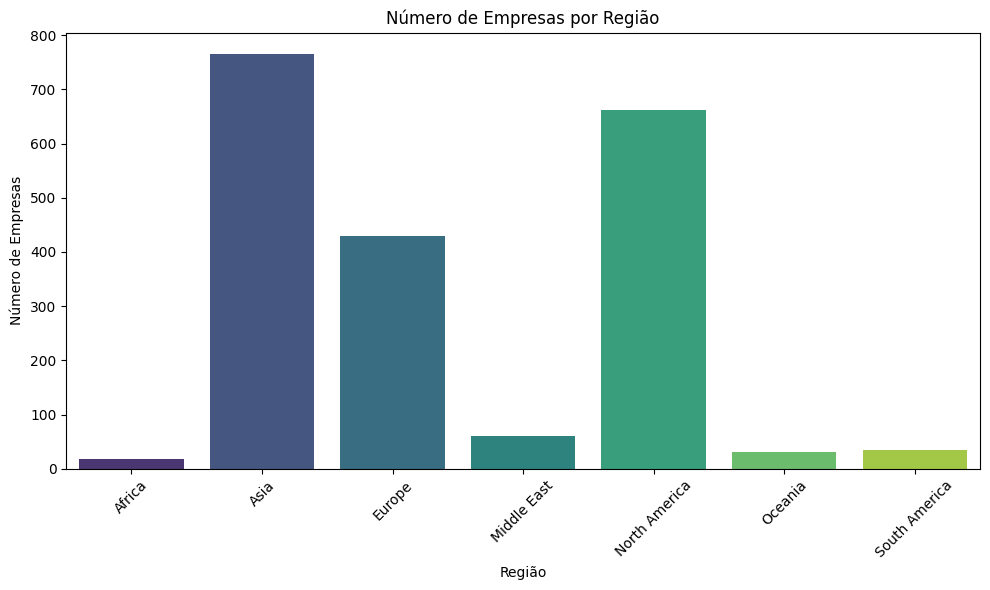

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=companies_by_region.index, y=companies_by_region.values, palette="viridis",hue=companies_by_region.index, legend=False)
plt.title("Número de Empresas por Região")
plt.xlabel("Região")
plt.ylabel("Número de Empresas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Tendo em conta os valores fornecidos, conseguimos apurar que a Ásia revela-se a região com o maior número de empresas, seguida da América do Norte. Agora, avaliemos quais são os setores mais presentes nas diversas regiões  

**Determinação do setor mais predominante por região:**

In [ ]:
# O lambda, para cada grupo, extrai os países únicos e ordena-os (fica mais curto que fazer um def)
dominant_sector = df_forbes_merged.groupby('region')['Industry'].apply(lambda x: x.value_counts().index[0])

print("\nSetor dominante por região:")
print(dominant_sector)


Setor dominante por região:
region
Africa                          Banking
Asia                            Banking
Europe                          Banking
Middle East                     Banking
North America    Diversified Financials
Oceania                         Banking
South America                 Materials
Name: Industry, dtype: object


Agora que possuimos conhecimento acerca dos principais setores nas diversas regiões, surge a curiosidade: porque é que uma dada região possui determinado setor como setor maioritário? porque é que, por exemplo, a América do Sul apresenta como setor maioritário o setor dos Materiais? De forma a decifrar os motivos da predominância dos mesmos, irei dividir os fatores explicativos em duas grandes dimensões: **geográficas** e **económicas.**

#Fatores Geográficos

A localização espacial de um dado território exerce muitas das vezes uma forte influência no contexto empresarial. A abundância de recursos naturais numa dada região favorece o surgimento de empresas relacionadas com a transformação de matérias primas.

Como pudemos constatar nos resultados anteriores, o setor predominante na América do Sul corresponde ao setor dos Materiais.

Para investigar mais a fundo quais os recursos existentes na América do Sul que proporcionam bases para o esenvolvimento de empreendorismo relacionado à sua exploração, analisemos as diversas empresas da América do Sul neste setor:

In [ ]:
#Obtenção das empresas de Materials na América do Sul
materiais_sul = df_forbes_merged[(df_forbes_merged['region'] == 'South America') & (df_forbes_merged['Industry'] == 'Materials')]

print("\nEmpresas de Materiais na América do Sul:\n")
print(materiais_sul[['Organization Name', 'Country']].to_string(index=False)) #aplicação do método to_string(index=False), de forma a remover o índice do print (só mesmo questão de estética)


Empresas de Materiais na América do Sul:

      Organization Name Country
                   Vale  Brazil
       Gerdau (Cosigua)  Brazil
Suzano Papel e Celulose  Brazil
                    CSN  Brazil
     Metalurgica Gerdau  Brazil
               Usiminas  Brazil


Como é possível observar, todas estas empresas possuem sede em território brasileiro. Estas empresas trabalham essencialmente com dois tipos de materiais:

* **Papel e celulose -** Suzana Papel e Celulose
* **Minérios(Ferro, Bauxite, Cobre, Niquel) -** Vale, Gerdeau, CSN, Metalurgica Gerdau, Usiminas

Nas empresas que se encontram na seção dos minérios, todas operam na área da mineração ou da metalurgia/siderurgia

De forma a validar a presença destas empresas na lista, irei suportar-me nos ficheiros tamanho_maior_floresta_por_continentes.csv e volume_minerios_por_região, que fornecem, tal como é explicito pela nomenclatura dos mesmos, dados acerca da maior floresta de cada região e a concentração de minérios da região (Número de minérios / área da região). Dado que o Brasil aparece como país único neste Setor, seria mais relevante analisar o mesmo á parte, ignorando a região à qual pertence

Carregamento dos dados das florestas

In [ ]:
df_forest = pd.read_csv("tamanho_maior_floresta_por_continentes.csv", na_values=na_vals)

**Visualização dos valores originais, relativos ao tamanho da maior floresta por região:**

In [ ]:
print("\nDados de tamanho de floresta:")
print(df_forest.to_string(index=False))


Dados de tamanho de floresta:
      Continente  Tamanho da maior floresta (em Milhares de km²)
  América do Sul                                         5500000
América do Norte                                         6600000
          África                                         1800000
          Europa                                         3900000
            Ásia                                         3900000
       Austrália                                            1200


Como podemos observar inicialmente, a Austrália apresenta um valor estrondosamente inferior aos restantes. Desta forma, faz sentido fazer uma fltragem onde os valores necessitam de possuir, pelos menos, 5% do maior valor ( max() ) presente nos dados:

In [ ]:
threshold = 0.05 * df_forest["Tamanho da maior floresta (em Milhares de km²)"].max()
df_forest_filtered = df_forest[df_forest["Tamanho da maior floresta (em Milhares de km²)"] >= threshold]


Agora com os dados filtrados, observemos os resultados finais:

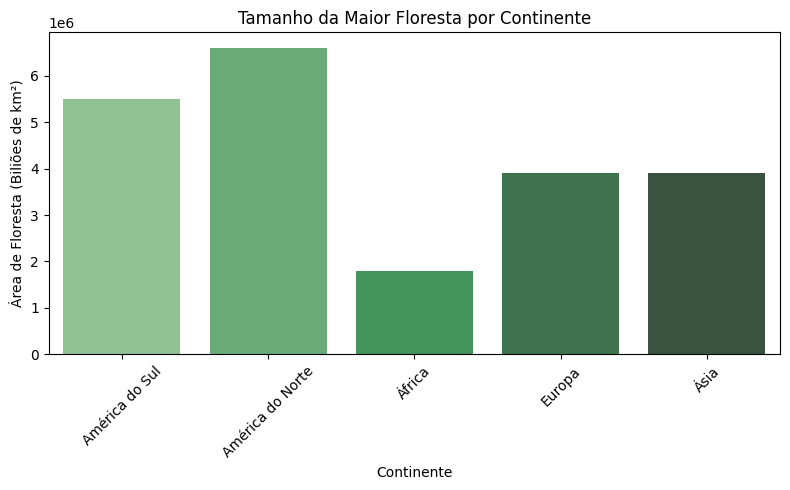

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x="Continente", y="Tamanho da maior floresta (em Milhares de km²)", data=df_forest_filtered, palette="Greens_d", hue="Continente", legend=False)
plt.title("Tamanho da Maior Floresta por Continente")
plt.xlabel("Continente")
plt.ylabel("Área de Floresta (Biliões de km²)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

No caso da América do Sul, esta floresta refere-se à floresta Amazónica. Como se pode constatar, a abundância de árvores no território brasileiro constitui uma fonte rica de papel, favorecendo imenso empresas como a Suzane Papel e Celulose. Analisemos, agora, a questão dos minérios:

Leitura e geração dos gráficos ilustrativos da concentração de minérios

Dados de volume de minerais:

       Região  Volume de Minérios (ferro, bauxita, cobre, níquel) em toneladas/km²
    Austrália                                                               130.60
       Brasil                                                                51.30
         Ásia                                                                30.30
Médio Oriente                                                                 7.11
       África                                                                 5.73


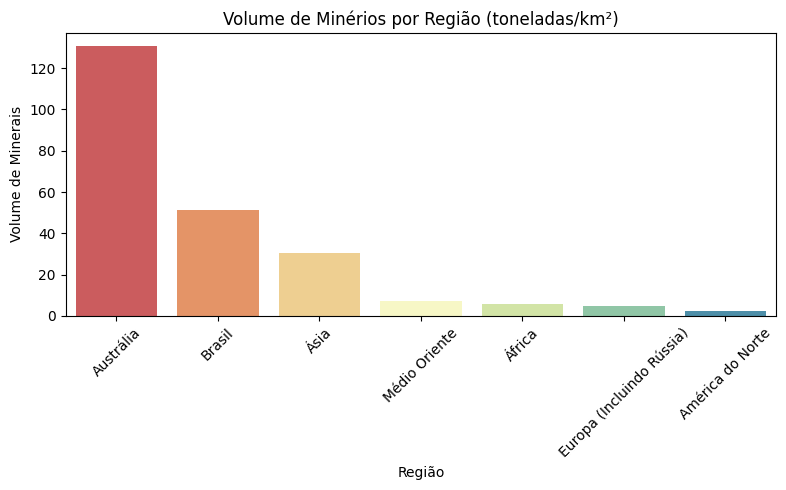

In [ ]:
df_minerals = pd.read_csv("volume_minerios_por_regiao.csv", na_values=na_vals)
print("Dados de volume de minerais:\n")
print(df_minerals.head().to_string(index=False))

plt.figure(figsize=(8,5))
sns.barplot(x="Região", y="Volume de Minérios (ferro, bauxita, cobre, níquel) em toneladas/km²", data=df_minerals, palette="Spectral", hue="Região", legend=False)
plt.title("Volume de Minérios por Região (toneladas/km²)")
plt.xlabel("Região")
plt.ylabel("Volume de Minerais")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Como é possível observar, o Brasil disfrute igualmente de uma vasta riqueza de metais, viabilizando a proliferação das indústrias de mineração, metalurgia e siderurgia presentes.

Apesar de não possuir nenhuma região que possua estes recursos como setor predominante, o petróleo e o gás natural são igualmente relevantes. Comecemos, inicialmente, por analisar o volume de petróleo por região, com o auxílio do ficheiro oil_reserves:2022.csv:

Leitura do ficheiro oil_reserves_2022.csv:

In [ ]:
df_oil = pd.read_csv("oil_reserves_2022.csv", na_values=na_vals)

Merge do mesmo com o ficheiro das regiões dos países, obtendo os dados por região.

Pretendi colocar a Rússia em separado, uma vez que, como irá ver posteriormente, este país apresenta uma elevada revelância nos setores petrolíferos e do gás natural

In [ ]:
#Função para por a Rússia de parte, considerando a região nos restantes países
def corrigir_regiao(row):
    if "Russia" in row["Country"]:
        return "Russia"
    else:
        return row["region"]

df_countries = pd.read_csv("countries_and_regions.csv")
df_oil_merged = pd.merge(df_oil, df_countries, on="Country", how="left")
df_oil_merged["region"] = df_oil_merged.apply(corrigir_regiao, axis=1)


Observação dos resultados do volume de Petróleo por região:


Reservas de petróleo por região (incluindo Rússia como separada):
region
Africa            40800.101
Asia              71800.500
Europe            13101.510
Middle East      537344.414
North America    242700.000
Oceania            1500.000
Russia           107800.000
South America     17909.000
Name: Oil Reserves (Million Barrels), dtype: float64


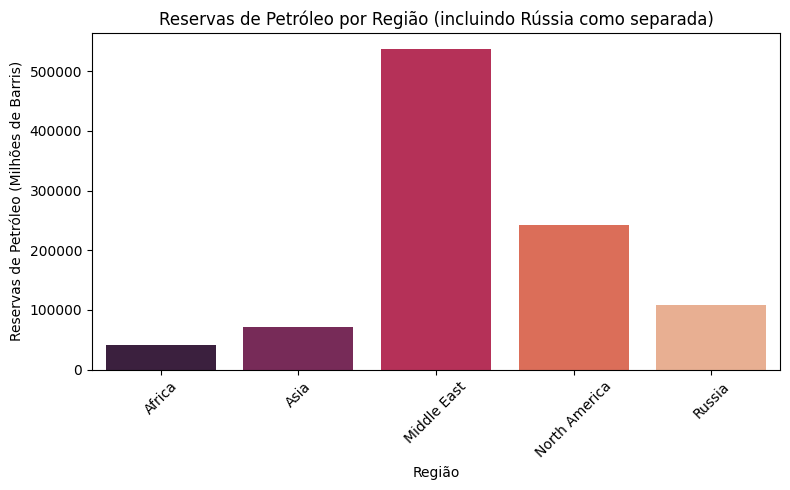

In [ ]:
oil_by_region = df_oil_merged.groupby("region")["Oil Reserves (Million Barrels)"].sum()
print("\nReservas de petróleo por região (incluindo Rússia como separada):")
print(oil_by_region)
#Foi definido um threshold para evitar o aparecimento de regiões elevadamente irrelevantes. No mínimo, para ser elegível, tem de ter pelo menos 5% do valor mais elevado
threshold_oil = oil_by_region.max() * 0.05
oil_filtered = oil_by_region[oil_by_region > threshold_oil]
plt.figure(figsize=(8,5))
sns.barplot(x=oil_filtered.index, y=oil_filtered.values, palette="rocket", hue=oil_filtered.index, legend=False)
plt.title("Reservas de Petróleo por Região (incluindo Rússia como separada)")
plt.xlabel("Região")
plt.ylabel("Reservas de Petróleo (Milhões de Barris)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Como é possível observar, os países do médio oriente possuem, de longe, o maior volume de reservas de petróleo. Isto explica o porquê da empresa do médio oriente que apresenta maior lugar no ranking encontrar-se no Setor de Oil & Gas Operations:

In [ ]:
middle_east_companies = df_forbes_merged[df_forbes_merged['region'] == 'Middle East']

#Com o iloc[0] e o sort_values, retiramos a primeira linha, correspiondente à empresa com melhor ranking do Médio Oriente
top_middle_east_company = middle_east_companies.sort_values(by='2022 Ranking').iloc[0]
print("\nEmpresa com maior ranking no Médio Oriente:")
print("Nome: {}, Setor: {}, País: {}, Ranking: {}".format(top_middle_east_company['Organization Name'],top_middle_east_company['Industry'],
top_middle_east_company['Country'],top_middle_east_company['2022 Ranking']))



Empresa com maior ranking no Médio Oriente:
Nome: Saudi Arabian Oil Company (Saudi Aramco), Setor: Oil & Gas Operations, País: Saudi Arabia, Ranking: 3


Agora, analisemos os dados da concentração de gás nas diversas regiões:

Gráfico ilustrativo do volume de gás


Dados de reservas de gás:
          Region  Gas Reserves (1000 bn standard cu m)
          Europe                                 22.05
            Asia                                 12.14
   Médio Oriente                                 82.34
  América do Sul                                  7.14
          Africa                                 17.94
          Russia                                 44.15
América do Norte                                 19.80


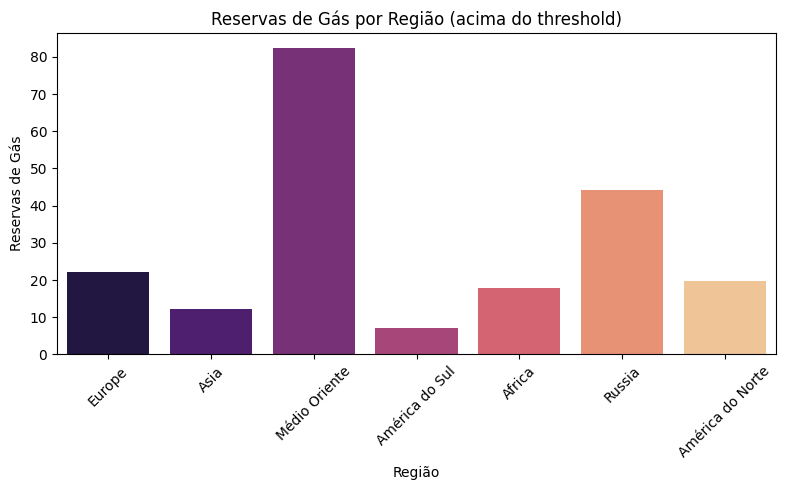

In [ ]:
df_gas = pd.read_csv("gas_reserves_2022.csv", na_values=na_vals) #Leitura do ficheiro
df_gas.dropna(inplace=True) #Remoção das linhas com valor nulo
print("\nDados de reservas de gás:")
print(df_gas.to_string(index=False))
threshold_gas = df_gas["Gas Reserves (1000 bn standard cu m)"].max() * 0.05 #corta do grafico valores com menos de 5% do maior
df_gas_filtered = df_gas[df_gas["Gas Reserves (1000 bn standard cu m)"] > threshold_gas]
plt.figure(figsize=(8,5))
sns.barplot(x="Region", y="Gas Reserves (1000 bn standard cu m)", data=df_gas_filtered, palette="magma", hue="Region", legend=False)
plt.title("Reservas de Gás por Região (acima do threshold)")
plt.xlabel("Região")
plt.ylabel("Reservas de Gás")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Como é expectável, o Médio Oriente encontra-se no topo. Contudo, é de destacar que a Rússia, sozinha, é a segunda maior região em termos de reservas de gás.

Isto explica o porquê do setor Oil & Operations ser o setor com maior predominância na Rússia, como é possível visualizar:

In [ ]:
russia_sectors = df_forbes_merged[df_forbes_merged['Country'].str.contains("Russia")]['Industry'].value_counts().head(2)
print("\nTop 2 setores mais predominantes na Rússia:")
print(russia_sectors)



Top 2 setores mais predominantes na Rússia:
Industry
Oil & Gas Operations    7
Materials               6
Name: count, dtype: int64


#Fatores Económicos

A análise da estrutura económica global permite compreender de que forma determinados setores se afirmam como predominantes no panorama empresarial internacional. O crescimento e a consolidação de setores como o bancário e o dos serviços financeiros diversificados são reflexo direto de dinâmicas económicas que favorecem a concentração de capital, a expansão do crédito e o papel central das finanças na economia moderna.

Neste contexto, torna-se essencial avaliar as empresas com base em indicadores económicos objetivos, capazes de refletir não só a sua dimensão, mas também a sua rentabilidade, influência e valor de mercado. Para tal, recorreu-se a quatro métricas-chave para analisar a base económica que sustenta a presença das maiores empresas no ranking global:

* **Capitalização de mercado (% do PIB) –** reflete a maturidade e o dinamismo dos mercados financeiros de um país.

* **Crédito interno ao setor privado (% do PIB) –** indica o nível de financiamento disponível às empresas e famílias, sendo essencial para o investimento e crescimento económico.

* **Emissão de títulos corporativos –** - Refere-se à captação de recursos por parte das empresas através da emissão de dívida no mercado financeiro, como obrigações (bonds).
Isso permite que as empresas se financiem fora do sistema bancário tradicional, diretamente com investidores, geralmente por meio dos mercados de capitais.

* **Investimento Direto Estrangeiro (IDE) –** revela o grau de atratividade económica de um país perante investidores internacionais.

Estas métricas foram fundamentais para interpretar os padrões observados na distribuição setorial e regional das empresas analisadas. Em particular, ajudam a explicar por que razão o setor financeiro surge como dominante: ele é diretamente beneficiado por contextos com alta liquidez, forte integração nos mercados globais e economias com elevado grau de capitalização e acesso ao crédito.



Preparação de estatísticas que envolvem valores percentuais, convertendo a vírgula decimal para ponto (padrão europeu para numérico) e valores irregulares em NaN

In [ ]:
def preparar_percentagens(df, coluna_valor):
    df[coluna_valor] = (df[coluna_valor].astype(str).str.replace(",", ".", regex=False))
    df[coluna_valor] = pd.to_numeric(df[coluna_valor], errors="coerce")
    return df

Agora, iremos analisar os resultados das 4 métricas por região. Para este efeito, possuo um .csv que armazena resultados dos diversos países em cada um dos critérios. Comecemos por analisar a Emissão de títulos corporativos:

Leitura do ficheiro e remoção de espaços brancos entre eles. Armazenamento dos valores em col_emissao para efetuar os gráficos

In [ ]:
df_emissao = pd.read_csv("emissao_titulos_corporativos.csv",na_values=na_vals)
df_emissao.columns = df_emissao.columns.str.strip()
col_emissao = df_emissao.columns[1]

Remoção de valores nulos

In [ ]:
df_emissao.dropna(inplace=True)

Gráfico ilustrativo dos resultados da emissão de títulos Corporativos

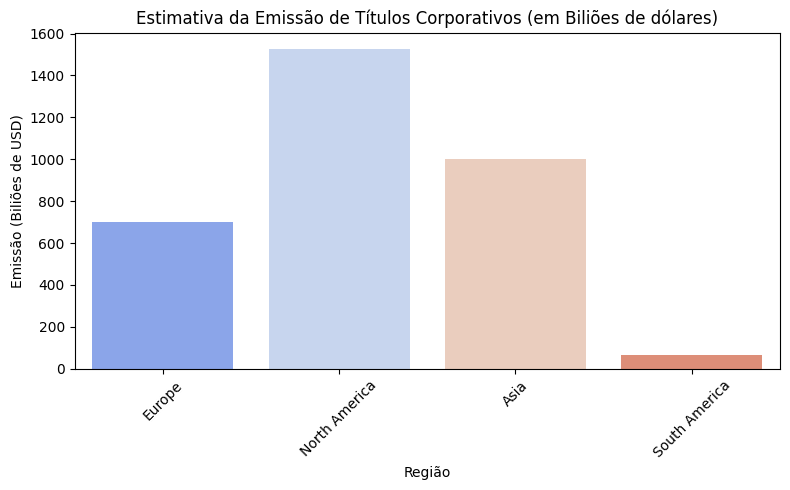

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Região", y=col_emissao, data=df_emissao, palette="coolwarm", hue="Região", legend=False)
plt.title("Estimativa da Emissão de Títulos Corporativos (em Biliões de dólares)")
plt.xlabel("Região")
plt.ylabel("Emissão (Biliões de USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O gráfico evidencia que a América do Norte lidera destacadamente a emissão de títulos corporativos, ultrapassando os 1.500 biliões de dólares. Este dado reflete a sofisticação e maturidade do mercado de capitais norte-americano, onde o financiamento das empresas é feito maioritariamente através da emissão de dívida no mercado, em vez de empréstimos bancários tradicionais.

Esta realidade está diretamente ligada à predominância do setor Diverse Financials na região, uma vez que este inclui bancos de investimento, companhias de seguros, holdings financeiras e outras entidades que operam intensamente no mercado de títulos. A forte presença destas instituições favorece, dinamiza e depende desse tipo de operação, reforçando assim o papel central do setor financeiro diversificado na economia norte-americana.

Agora, analisemos o Crédito Interno ao Setor Privado.

Leitura do ficheiro associado à métrica

In [ ]:
df_credito = pd.read_csv("credito_interno_ao_setor_privado.csv", encoding="ISO-8859-1", na_values=na_vals)

Como o ficheiro não se encontra agrupado por regiões (tem apenas os diversos países), efetuamos o merge com o ficheiro dos países:

In [ ]:
df_credito.columns = ["Country", "Credito (% PIB)"] #Renomear as colunas, de modo a facilitar a leitura
df_credito = pd.merge(df_credito, df_countries, on="Country", how="left")

Utilizaremos a função criada para certificar que as percentagens estão corretamente formatadas:

In [ ]:
df_credito = preparar_percentagens(df_credito, "Credito (% PIB)")

Agrupar os diversos países pelas regiões propostas no .csv. os valores de cada região corresponderão á média das percentagens dos países da mesma

In [ ]:
df_credito_grouped = df_credito.groupby("region")["Credito (% PIB)"].mean().sort_values(ascending=False)

Gráfico ilustrativo dos resultados do credito interno

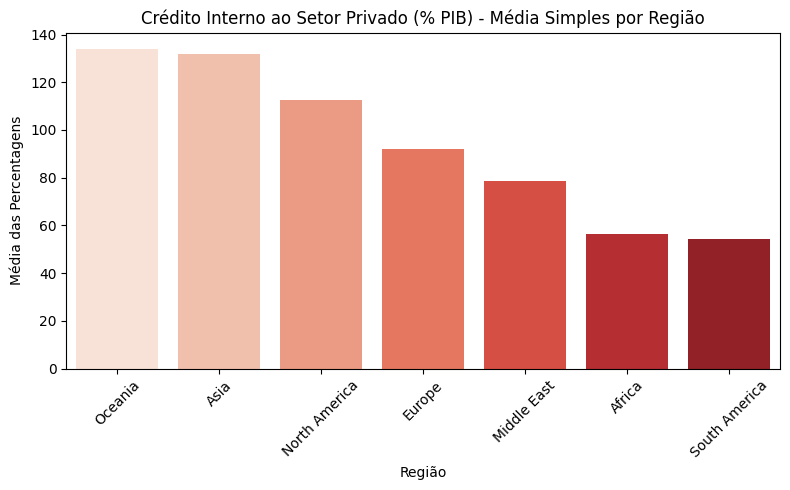

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df_credito_grouped.index, y=df_credito_grouped.values, palette="Reds", hue=df_credito_grouped.index, legend=False)
plt.title("Crédito Interno ao Setor Privado (% PIB) - Média Simples por Região")
plt.xlabel("Região")
plt.ylabel("Média das Percentagens")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Como se pode ver, a Ásia possui uma média bastante elevada de crédito interno ao setor privado, superando os 130% do PIB, o que significa que o sistema financeiro local é altamente desenvolvido, com amplo acesso a financiamento para empresas e famílias.

No caso da Oceania, a Austrália tem forte integração entre o setor bancário e o setor produtivo, com elevado nível de financiamento privado. Como é o único país da Região, o valor médio reflete exclusivamente a realidade australiana, o que justifica o lugar de topo da tabela

Como se pode ver, a América do Norte regista valores médios acima de 110%, o que significa que o setor privado tem acesso significativo a crédito, refletindo um sistema financeiro maduro e dinâmico.

Já a Europa e o Médio Oriente apresentam valores moderados, entre 80% e 90% do PIB, o que significa que, embora exista acesso ao crédito, este é mais contido, possivelmente devido a regulamentações mais conservadoras, diferenças estruturais ou modelos económicos menos dependentes de financiamento privado.

Por sua vez, a África e a América do Sul têm falta de crédito ao setor privado, com médias inferiores a 60% do PIB, o que pode indicar sistemas financeiros menos desenvolvidos, menor inclusão bancária e maiores barreiras ao financiamento para empresas e consumidores.

Agora, analisemos a capitalização do mercado (% do PIB)

Leitura do ficheiro com os dados da capitalização do mercado, eliminação de dados nulos e merge com o ficheiro das regiões, obtendo a região do país

In [ ]:
df_capitalizacao = pd.read_csv("capitalizacao_mercado_por_pais.csv", encoding="ISO-8859-1", na_values=na_vals)
df_capitalizacao.columns = ["Country", "Capitalizacao de Mercado(% PIB)"]

df_capitalizacao.dropna(inplace=True)

df_capitalizacao = pd.merge(df_capitalizacao, df_countries, on="Country", how="left")
df_capitalizacao = preparar_percentagens(df_capitalizacao, "Capitalizacao de Mercado(% PIB)") #Formatar corretamente as percentagens, como já mencionado

Tal como no caso anterior, efetuaremos a média dos valores por região (ordenando alfabeticamente as mesmas):

In [ ]:
df_cap_grouped = df_capitalizacao.groupby("region")["Capitalizacao de Mercado(% PIB)"].mean().sort_values(ascending=False)

print(df_cap_grouped)

region
Asia             190.938462
Africa           107.600000
Middle East      101.342857
Oceania           99.300000
North America     78.900000
Europe            74.409524
South America     38.540000
Name: Capitalizacao de Mercado(% PIB), dtype: float64


Gráfico ilustrativo dos resultados da capitalização de mercado

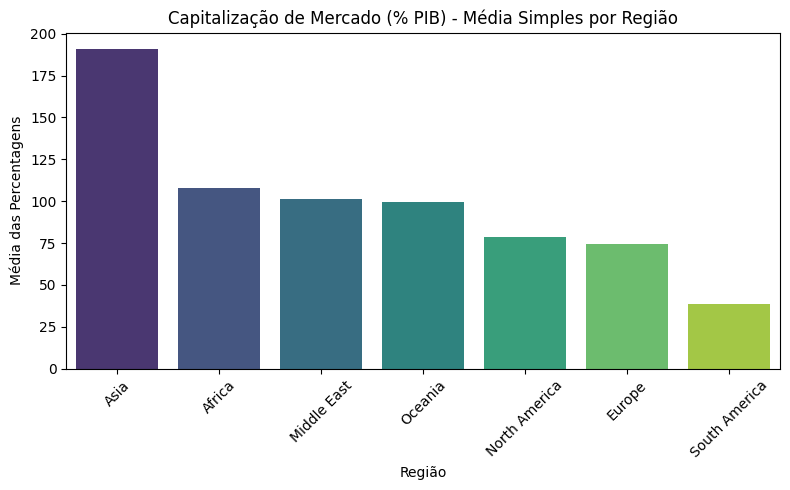

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df_cap_grouped.index, y=df_cap_grouped.values, palette="viridis", hue=df_cap_grouped.index, legend=False)
plt.title("Capitalização de Mercado (% PIB) - Média Simples por Região")
plt.xlabel("Região")
plt.ylabel("Média das Percentagens")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Como se pode ver, a Ásia possui a média mais elevada de capitalização de mercado em percentagem do PIB, ultrapassando os 190%, o que significa que o mercado bolsista da região é extremamente desenvolvido, refletindo um elevado valor de empresas cotadas em relação ao tamanho das economias.

Como se pode ver, o Médio Oriente e a Oceania apresentam valores médios na casa dos 100%, o que significa que os seus mercados de capitais têm um papel relevante na economia, com uma presença significativa de empresas cotadas nas bolsas locais.

Como se pode ver, a América do Norte e a Europa apresentam valores mais moderados, entre 70% e 80% do PIB, o que significa que, embora sejam mercados maduros e sofisticados, a capitalização relativa pode estar diluída devido à diversidade económica e ao grande tamanho do PIB dessas regiões.

Já a América do Sul tem falta de capitalização de mercado, com valores médios abaixo de 50% do PIB, o que indica mercados de capitais menos desenvolvidos, com poucas empresas cotadas e menor participação da bolsa como fonte de financiamento.

Por fim, a África surge com um valor médio surpreendentemente elevado (acima de 100% do PIB); no entanto, este resultado está claramente inflacionado pela extrema percentagem da África do Sul, cujo mercado bolsista é altamente desenvolvido, ao contrário da generalidade dos países africanos, que têm níveis muito baixos ou inexistentes de capitalização de mercado, tal como é possível observar em baixo:

Valor da Capitalização (%PIB) da África

In [ ]:
africa_capitalizacao = df_capitalizacao[df_capitalizacao['region'] == 'Africa'][['Country', 'Capitalizacao de Mercado(% PIB)']] #Seleção das colunas pretendidas para visualização (no caso o país e o seu valor de capitalização)

#ascending = false de forma a ficar em ordem decrescente: maior valor em cima, menor em baixo
africa_capitalizacao = africa_capitalizacao.sort_values('Capitalizacao de Mercado(% PIB)', ascending=False)

print("Países africanos e sua capitalização (% PIB):\n")
print(africa_capitalizacao.to_string(index=False))

Países africanos e sua capitalização (% PIB):

     Country  Capitalizacao de Mercado(% PIB)
South Africa                            348.3
     Morocco                             41.0
       Egypt                             21.8
     Nigeria                             19.3


Estes valores refletem-se igualmente no número de empresas em África, pois quanto maior a capitalização de mercado, maior tende a ser o número de empresas, pois há mais companhias grandes e valorizadas na bolsa.

In [ ]:
print(df_forbes_merged[df_forbes_merged.region=='Africa'].groupby('Country').size().sort_values(ascending=False))

Country
South Africa    13
Morocco          2
Egypt            1
Nigeria          1
dtype: int64


Por fim, abordaremos a métrica do investimento direto estrangeiro (IDE)

Leitura do ficheiro com os dados do IDE e merge com o ficheiro das regiões, obtendo a região do país

In [ ]:
df_investimento = pd.read_csv("investimento_direto_estrangeiro.csv", encoding="ISO-8859-1", na_values=na_vals)
df_investimento.columns = ["Country", "IDE (US$ bilhões)"]
df_investimento = pd.merge(df_investimento, df_countries, on="Country", how="left")
df_investimento = preparar_percentagens(df_investimento, "IDE (US$ bilhões)")

Obter a soma do investimento por região

In [ ]:
df_ide_grouped = df_investimento.groupby("region")["IDE (US$ bilhões)"].sum().sort_values(ascending=False)

Observação dos Resultados

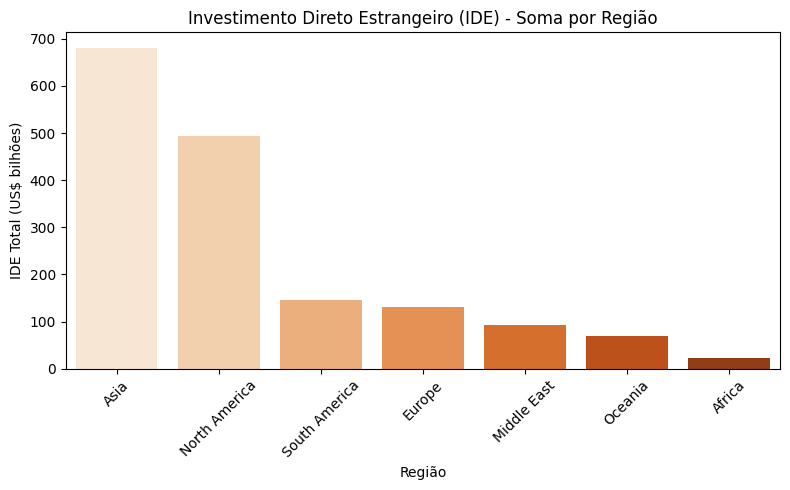

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df_ide_grouped.index, y=df_ide_grouped.values, palette="Oranges", hue=df_ide_grouped.index, legend=False)
plt.title("Investimento Direto Estrangeiro (IDE) - Soma por Região")
plt.xlabel("Região")
plt.ylabel("IDE Total (US$ bilhões)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Como se pode ver, a Ásia possui o maior volume de Investimento Direto Estrangeiro, o que significa que é a região mais atrativa para investidores internacionais, com economias em rápido crescimento, estabilidade relativa e oportunidades de mercado.

Como se pode ver, a América do Norte também apresenta um valor elevado de IDE, o que significa que continua a ser uma região segura e atrativa para grandes investimentos globais, com forte infraestrutura e previsibilidade regulatória.

Como se pode ver, a América do Sul e a Europa apresentam valores moderados, o que significa que, embora recebam investimento estrangeiro, não se destacam tanto em escala global quanto Ásia ou América do Norte.

Como se pode ver, o Médio Oriente e a Oceania têm níveis mais baixos de IDE, o que significa menor captação de capital externo — possivelmente por fatores como instabilidade política (no caso do Médio Oriente) ou menor escala económica (no caso da Oceania).

Já a África tem falta de investimento direto estrangeiro, com o menor volume entre as regiões, o que indica uma menor atratividade para investidores internacionais, causada por fatores como instabilidade, riscos económicos e baixa diversificação industrial.

#Conclusões gerais

* A Ásia representa a região mais dinâmica em termos económicos, liderando em quase todas as métricas, o que justifica o seu lugar como região com mais empresas do planeta, dominando no setor de Banking

* A América do Norte destaca-se pela profundidade dos seus mercados de capitais, elevada emissão de títulos e grande presença de empresas, o que reforça o seu papel como centro económico global e realça o seu reforço no setor de Diversed Finances.

* A Europa apresenta estabilidade económica e uma presença relevante no ranking, com destaque para a predominância de empresas ligadas ao setor bancário, reflexo de um modelo mais tradicional onde o financiamento empresarial ainda depende significativamente dos bancos em vez dos mercados de capitais.

* O Médio Oriente apresenta um desempenho intermédio, onde apesar da relevância das matérias-primas como o petróleo, o setor financeiro é o mais representado, refletindo uma forte dependência de instituições bancárias no funcionamento económico da região.

* A Oceania apresenta bons indicadores económicos e estabilidade financeira, mas os dados podem não refletir a realidade da região como um todo, já que são baseados exclusivamente na Austrália, o único país com representação significativa no ranking.

* A América do Sul tem fraca representação empresarial e baixos indicadores de capitalização, crédito e IDE, apoiando-se na riqueza dos seus recursos para gerar riqueza

* A África possui indicadores económicos extremamente baixos(exceto em África do Sul), onde a fraca atratividade económica dificulta a criação de empresas e gera dependência dos bancos

**Curiosidade**: As empresas portuguesas que se encontram na lista são as seguintes:

In [ ]:
portuguese_companies = df_forbes_merged.loc[df_forbes_merged["Country"].str.contains("Portugal", na=False)]
print("\nEmpresas portuguesas no Forbes Global 2000 de 2022:")
print(portuguese_companies[['2022 Ranking', 'Organization Name']].to_string(index=False))


Empresas portuguesas no Forbes Global 2000 de 2022:
 2022 Ranking         Organization Name
          666  Edp-energias De Portugal
         1228          Jeronimo Martins
         1375              Galp Energia
         1652 Banco Comercial Portugues


#**Pergunta 2 - Quais são os setores mais lucrativos e como se relacionam com a receita, valorização de mercado, a empregabilidade e o uso dos ativos?**

Identificar os setores mais lucrativos é fundamental para compreender onde se concentra o maior retorno financeiro dentro do universo empresarial global. No entanto, a análise da rentabilidade isolada pode ser limitada, pelo que é igualmente relevante perceber como ela se relaciona com outros indicadores económicos, como a receita, o valor de mercado e a empregabilidade.

Setores que apresentam elevados lucros nem sempre são os que mais empregam ou geram maior volume de negócios. Da mesma forma, uma margem de lucro elevada pode coexistir com uma base operacional mais enxuta. Esta análise permite, assim, comparar não apenas a rentabilidade absoluta e relativa dos setores, mas também a sua eficiência económica e impacto social, ajudando a traçar um retrato mais completo das indústrias que lideram o mercado global.

Inicialmente, iremos agora calcular aquilo que são os setores mais rentáveis com base nas duas categorias que serão basilares das métricas mais específicas que iremos abordar: **Lucro Absoluto** e **Margem de Lucro Média (Lucro Relativo Médio)**

* **Lucro Absoluto -** Soma absoluta, por setor, dos respetivos valores de profit

* **Margem de Lucro Média (Lucro Relativo Médio)** - Percentagem dos valores da receita que se traduzem em lucro, em média, por setor (ou seja, profits/receita)

Preparação dos dados (conversão dos dados de empregados para numérico, evitando erros, função de cálculo do lucro relativo e seleção das colunas relevantes)

In [ ]:
df_forbes['Total Employees'] = pd.to_numeric(df_forbes['Total Employees'], errors='coerce')

df_forbes['ProfitMargin_%'] = (df_forbes['Profits (Billions)'] / df_forbes['Revenue (Billions)']) * 100

df_clean = df_forbes[[
    'Organization Name', 'Industry', 'Country',
    'Revenue (Billions)', 'Profits (Billions)', 'ProfitMargin_%',
    'Market Value (Billions)', 'Total Employees','Assets (Billions)'
]].copy()

Agrupamento dos valores de lucro absoluto (apenas soma dos valores por setor, como se pode ver em sum) e lucro relativo (média dos valores, como se pode ver em mean)

In [ ]:
lucros_totais = df_clean.groupby('Industry')['Profits (Billions)'].sum().reset_index()
margens_medias = df_clean.groupby('Industry')['ProfitMargin_%'].mean().reset_index()

sector_profit_df = pd.merge(lucros_totais, margens_medias, on='Industry')

#Lucro Absoluto por Setor

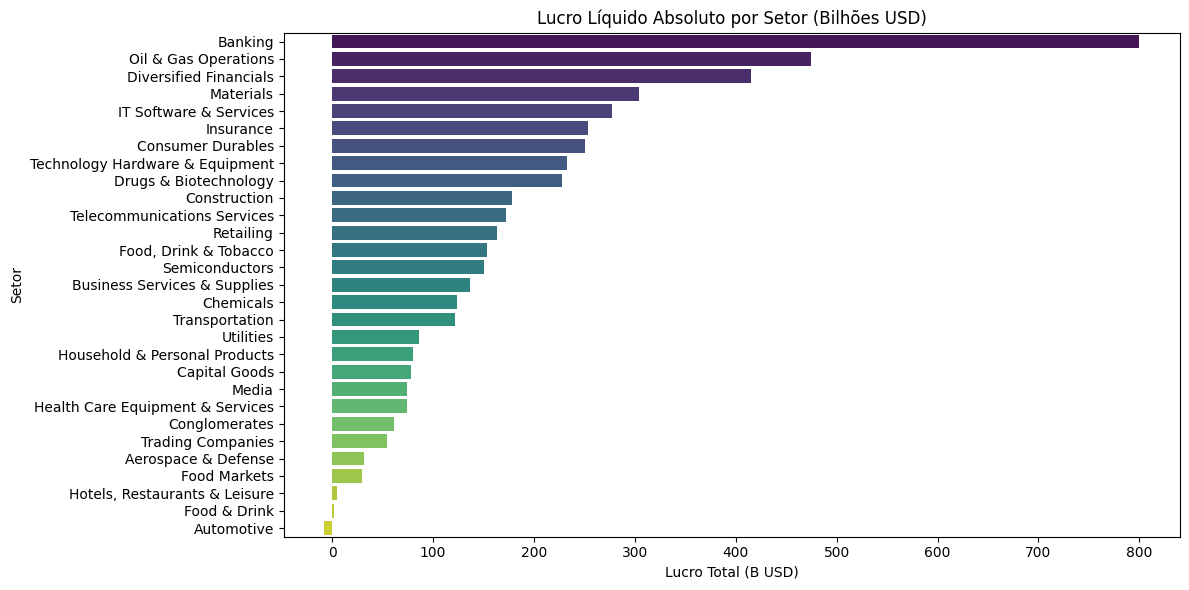

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=sector_profit_df.sort_values(by='Profits (Billions)', ascending=False),
            x='Profits (Billions)', y='Industry', palette='viridis', hue='Industry', legend=False)
plt.title('Lucro Líquido Absoluto por Setor (Bilhões USD)')
plt.xlabel('Lucro Total (B USD)')
plt.ylabel('Setor')
plt.tight_layout()
plt.show()

Como podemos ver, o setor de Banking encontra-se isoladamente no topo, fazendo sentido com os dados da pergunta anterior, onde a região com maior poder económico/número de empresas (Ásia) possui banking como setor primário, bem como a maioria das regiões no geral. Desta forma, existem muitas somas de lucros, favorecendo o resultado. Podemos ver igualmente que setores mencionados anteriormente (Oil & Gas Operations, Diversed Finances, Materials) são altamente lucrativos. É de destacar igualmente que o setor Automotive encontra-se em prejuízo, apresentando valores negativos de lucro

Margem de Lucro Média (Lucro Relativo) por Setor:

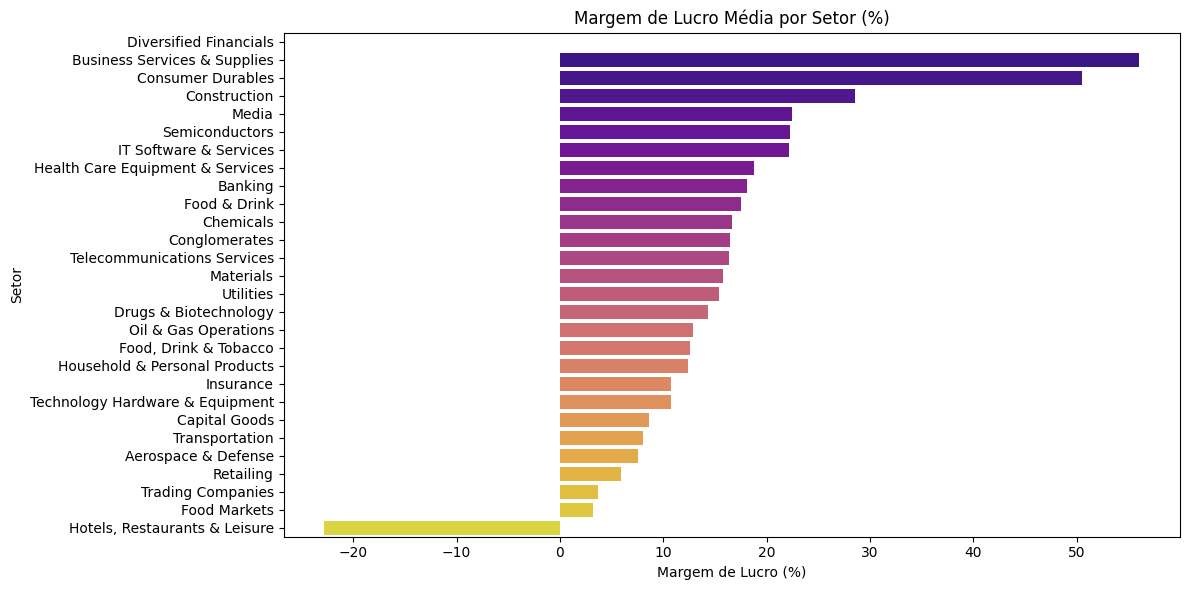

In [ ]:
sector_profit_filtered = sector_profit_df[sector_profit_df['Industry'] != 'Automotive']

plt.figure(figsize=(12, 6))
sns.barplot(data=sector_profit_filtered.sort_values(by='ProfitMargin_%', ascending=False),
            x='ProfitMargin_%', y='Industry', palette='plasma', hue='Industry', legend=False)
plt.title('Margem de Lucro Média por Setor (%)')
plt.xlabel('Margem de Lucro (%)')
plt.ylabel('Setor')
plt.tight_layout()
plt.show()

Como é possível observar, o setor de Diversed Finances revela-se o setor mais eficiente, uma vez que é o setor onde a relação rendimentos -> lucro é mais elevada.

Podemos igualmente observar que o setor hotels, restaurants & leisure apresenta uma margem de lucro negativa, ou seja, os rendimentos foram menores que os gastos que o mesmo teve

Neste gráfico em particular, tivemos que remover o setor Autumotive, uma vez que este apresenta uma margem de lucro horrenda, o que impossibilitava a visualização concreta dos setores restantes

Visualização da margem de lucro do setor automotive

In [ ]:
sector_profit_df.loc[sector_profit_df['Industry'] == 'Automotive']

,Industry,Profits (Billions),ProfitMargin_%
1,Automotive,-7.72,-8958.333333


As empresas do setor em questão

In [ ]:
df_forbes.loc[df_forbes['Industry'] == 'Automotive']

,2022 Ranking,Organization Name,Industry,Country,Year Founded,Revenue (Billions),Profits (Billions),Assets (Billions),Market Value (Billions),Total Employees,ProfitMargin_%
1439,1440,Rivian,Automotive,United States,2009,0.06,-4.69,22.29,30.27,10422.0,-7816.666667
1783,1784,Lucid Motors,Automotive,United States,2018,0.03,-3.03,7.88,31.59,3900.0,-10100.000000


Em suma, como podemos ver, o setor Automotive apresentou uma margem de lucro de -8000%. Isto deve-se ao facto de as empresas presentes na lista (Rivian e Lucid Motors) serem startups de carros elétricos. Ao terem sido fundas recentemente, ainda estão em fase de crescimento com altos custos de produção, investimento em tecnologia e infraestrutura, mas baixo volume de vendas, o que é típico em startups automotivas.

Para compreender melhor os fatores impulsionadores do lucro e aquilo que podem ser os seus valores ideais, analisemos agora a correlação entre o profit e os quatro parâmetros sugeridos na questão:

* Receita (revenue) - total de rendimentos obtidos pelas empresas
* Valor de Mercado - valorização total das empresas no mercado financeiro
* Empregabilidade - Indica o número médio de trabalhadores por setor
* ROA - Mede a eficiência com que as empresas utilizam os seus ativos para gerar lucro - quanto maior o ROA, maior o retorno obtido por cada unidade de ativo disponível

Agrupamento dos dados por setor (Industry), com cálculo da média de diferentes métricas  
para análise comparativa entre setores:
* **sector_growth_df:** receita, lucro e margem de lucro média
* **sector_market_df:** valor de mercado, lucro e margem
* **sector_employment_df:** número médio de empregados, lucro e margem
* **sector_roa_df:** ativos, lucro e margem, para posterior cálculo do ROA

In [ ]:
sector_growth_df = df_clean.groupby('Industry').aggregate({
    'Revenue (Billions)': 'mean',
    'Profits (Billions)': 'mean',
    'ProfitMargin_%': 'mean'
}).reset_index()

sector_market_df = df_clean.groupby('Industry').aggregate({
    'Market Value (Billions)': 'mean',
    'Profits (Billions)': 'mean',
    'ProfitMargin_%': 'mean'
}).reset_index()

sector_employment_df = df_clean.groupby('Industry').aggregate({
    'Total Employees': 'mean',
    'Profits (Billions)': 'mean',
    'ProfitMargin_%': 'mean'
}).reset_index()

sector_roa_df = df_clean.groupby('Industry').aggregate({
    'Assets (Billions)': 'mean',
    'Profits (Billions)': 'mean',
    'ProfitMargin_%': 'mean'
}).reset_index()




Cálculo do ROA (Quanto mais profit conseguirem gerar com os ativos que têm melhor)

In [ ]:
sector_roa_df['ROA (%)'] = (sector_roa_df['Profits (Billions)'] / sector_roa_df['Assets (Billions)']) * 100

Em seguida, iremos observar as quatro métricas, relativamente ao lucro absoluto e lucro relativo, estudando a associação entre estas métricas e o profit bruto com a eficiência, utilizando gráficos de pontos (cada um representativo de um setor), com o intuito de permitir a análise das tendências. Uma vez que os setores industriais são os mesmos para os oito plots, utilizo scatterplots para juntar os gráficos todos num só espaço. Os resultados são os seguintes:

**Nota:** Tivemos de retirar o setor Automotive dos gráficos com margem de lucro, uma vez que a sua percentagem extremamente negativa, como demonstrado, impossibilita a visualização dos dados

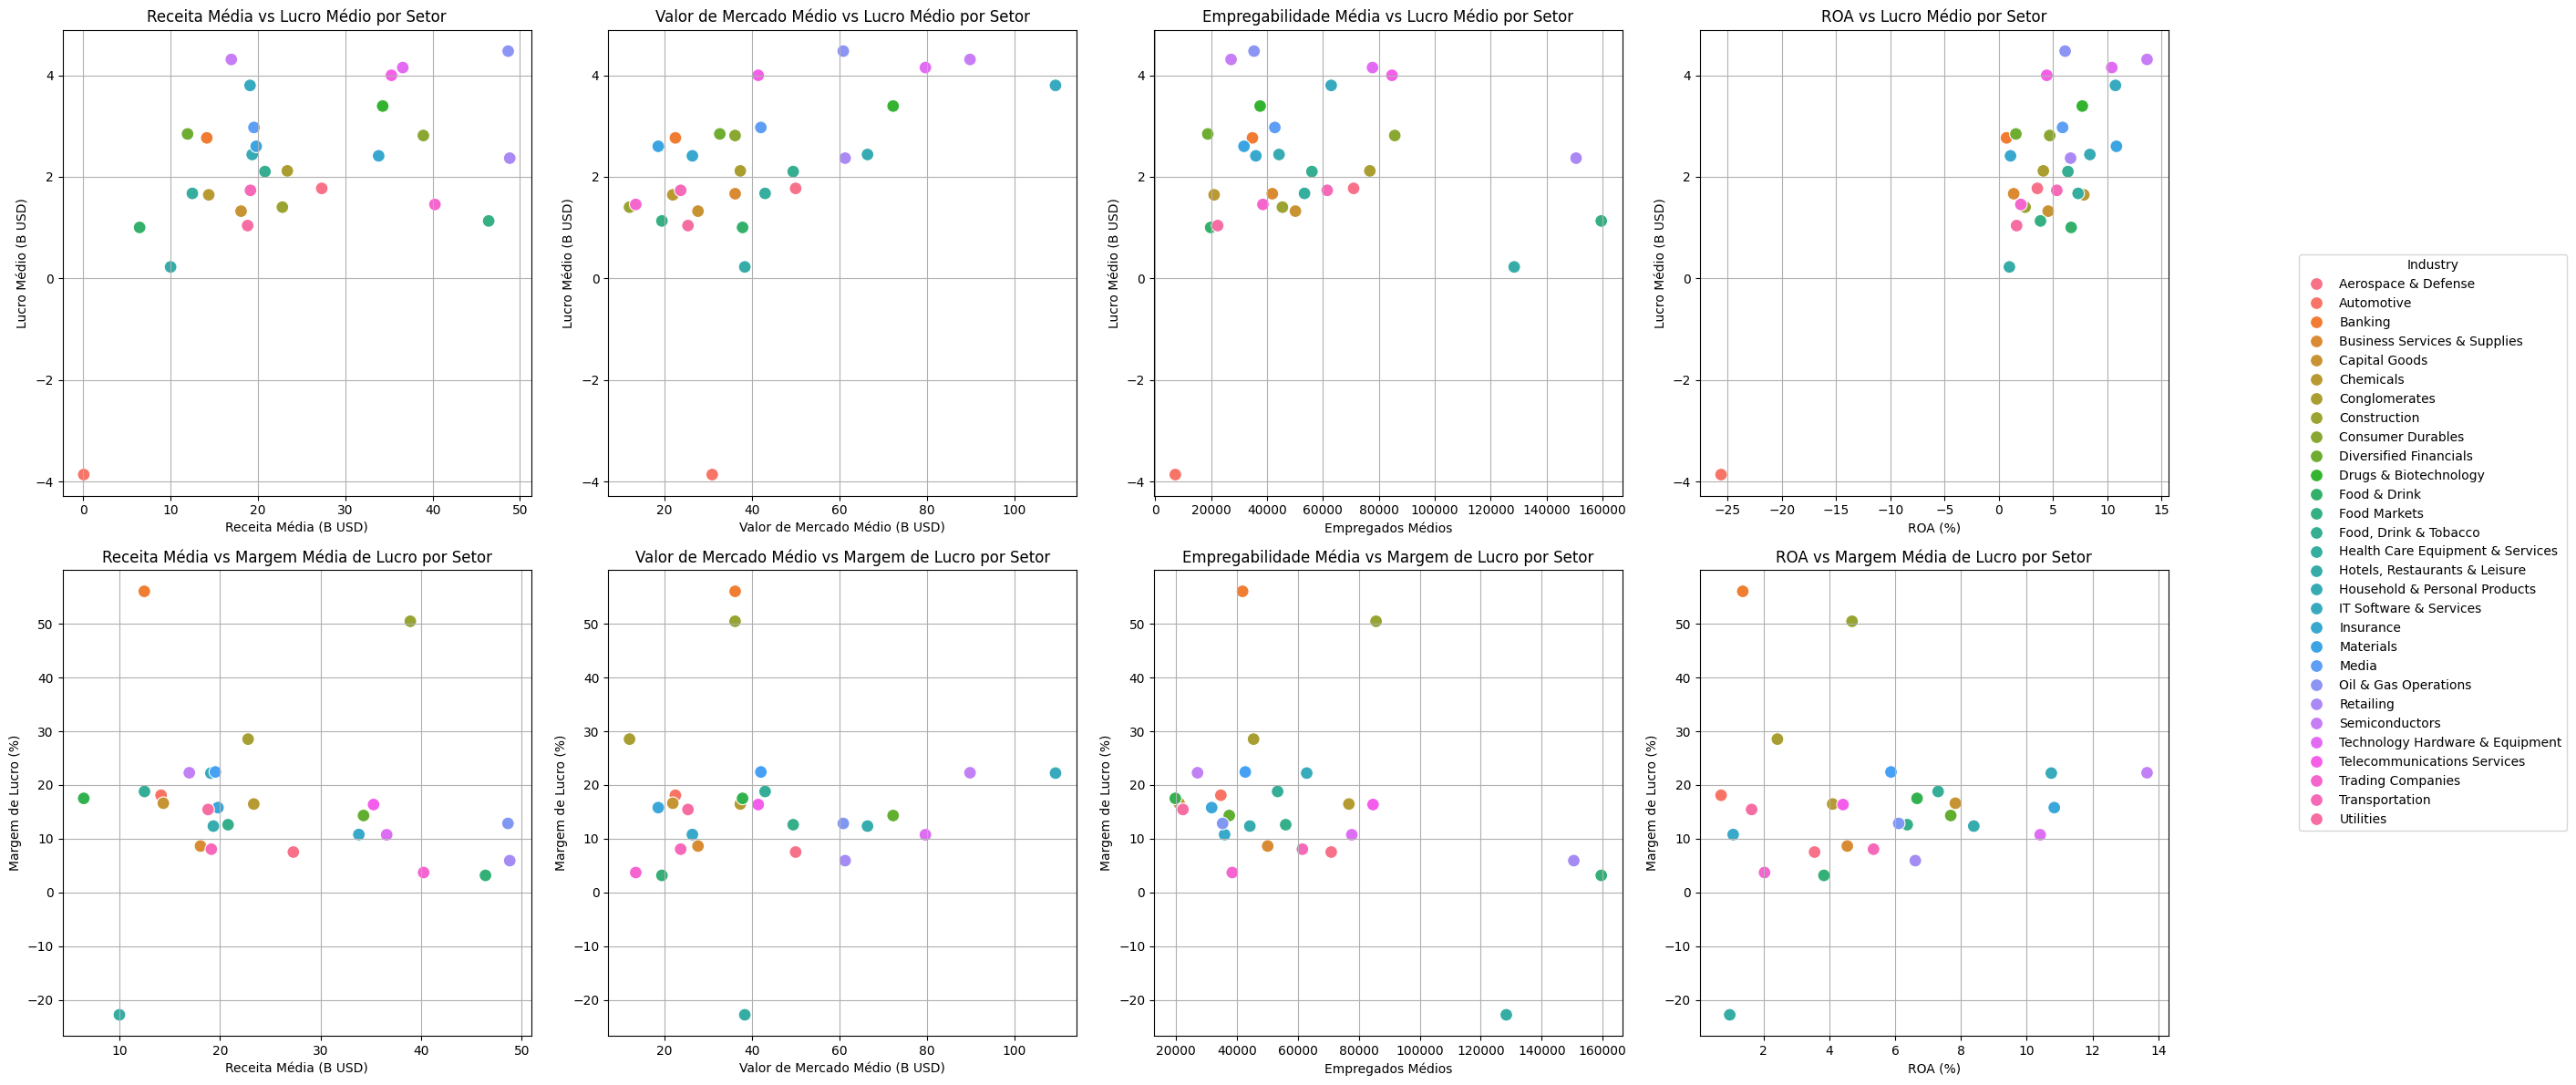

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

sns.scatterplot(data=sector_growth_df, x='Revenue (Billions)', y='Profits (Billions)', hue='Industry', s=100, ax=axes[0, 0], legend=True)
axes[0, 0].set_title('Receita Média vs Lucro Médio por Setor')
axes[0, 0].set_xlabel('Receita Média (B USD)')
axes[0, 0].set_ylabel('Lucro Médio (B USD)')
axes[0, 0].grid(True)

axes[0, 0].legend_.remove() #Remoção da legenda de forma a não estar repetido

sns.scatterplot(data=sector_market_df, x='Market Value (Billions)', y='Profits (Billions)', hue='Industry', s=100, ax=axes[0, 1], legend=False)
axes[0, 1].set_title('Valor de Mercado Médio vs Lucro Médio por Setor')
axes[0, 1].set_xlabel('Valor de Mercado Médio (B USD)')
axes[0, 1].set_ylabel('Lucro Médio (B USD)')
axes[0, 1].grid(True)

sns.scatterplot(data=sector_employment_df, x='Total Employees', y='Profits (Billions)', hue='Industry', s=100, ax=axes[0, 2], legend=False)
axes[0, 2].set_title('Empregabilidade Média vs Lucro Médio por Setor')
axes[0, 2].set_xlabel('Empregados Médios')
axes[0, 2].set_ylabel('Lucro Médio (B USD)')
axes[0, 2].grid(True)

sns.scatterplot(data=sector_roa_df, x='ROA (%)', y='Profits (Billions)', hue='Industry', s=100, ax=axes[0, 3], legend=False)
axes[0, 3].set_title('ROA vs Lucro Médio por Setor')
axes[0, 3].set_xlabel('ROA (%)')
axes[0, 3].set_ylabel('Lucro Médio (B USD)')
axes[0, 3].grid(True)

sector_growth_df_filtered = sector_growth_df[sector_growth_df['Industry'] != 'Automotive']
sector_market_df_filtered = sector_market_df[sector_market_df['Industry'] != 'Automotive']
sector_employment_df_filtered = sector_employment_df[sector_employment_df['Industry'] != 'Automotive']
sector_roa_df_filtered = sector_roa_df[sector_roa_df['Industry'] != 'Automotive']

sns.scatterplot(data=sector_growth_df_filtered, x='Revenue (Billions)', y='ProfitMargin_%', hue='Industry', s=100, ax=axes[1, 0], legend=False)
axes[1, 0].set_title('Receita Média vs Margem Média de Lucro por Setor')
axes[1, 0].set_xlabel('Receita Média (B USD)')
axes[1, 0].set_ylabel('Margem de Lucro (%)')
axes[1, 0].grid(True)

sns.scatterplot(data=sector_market_df_filtered, x='Market Value (Billions)', y='ProfitMargin_%', hue='Industry', s=100, ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Valor de Mercado Médio vs Margem de Lucro por Setor')
axes[1, 1].set_xlabel('Valor de Mercado Médio (B USD)')
axes[1, 1].set_ylabel('Margem de Lucro (%)')
axes[1, 1].grid(True)

sns.scatterplot(data=sector_employment_df_filtered, x='Total Employees', y='ProfitMargin_%', hue='Industry', s=100, ax=axes[1, 2], legend=False)
axes[1, 2].set_title('Empregabilidade Média vs Margem de Lucro por Setor')
axes[1, 2].set_xlabel('Empregados Médios')
axes[1, 2].set_ylabel('Margem de Lucro (%)')
axes[1, 2].grid(True)

sns.scatterplot(data=sector_roa_df_filtered, x='ROA (%)', y='ProfitMargin_%', hue='Industry', s=100, ax=axes[1, 3], legend=False)
axes[1, 3].set_title('ROA vs Margem Média de Lucro por Setor')
axes[1, 3].set_xlabel('ROA (%)')
axes[1, 3].set_ylabel('Margem de Lucro (%)')
axes[1, 3].grid(True)

handles, labels = axes[0, 0].get_legend_handles_labels() #Utiliza a legenda presente no plot correspondente a [0,0]. Assim, a legenda fica do lado direito, de forma ideal
fig.legend(handles, labels, title='Industry', bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()
plt.show()




#Conclusões Gerais

* Como seria de esperar, tanto o aumento da receita como o aumento do valor de mercado geram, em uma proporção moderada, maior valor de lucro absoluto. O mesmo se verifica para o ROA de uma forma bastante clara e significativa, demonstrando que quanto maior a eficiência na gestão de recursos, maior o lucro absoluto. Contudo, o aumento dos mesmos não se revela sinónimo evidente de aumento de eficiência, embora discutivelmente possa apresentar alguma correlação no caso do valor de mercado médio e do ROA
* Em relação aos empregados, podemos testemunhar uma espécie de relação inversa, onde geralmente as empresas mais lucrativa e eficientes possuem um valor consideravelmente baixo de empregabilidade. Estes valores podem estar relacionados com o menor custo de salários, menor necessidade de expansão de infraestruturas para acolher altos volumes de pessoal e até mesmo melhor cooperação, aumentando a agilidade e eficiência

#**Pergunta 3 - Quais as empresas mais antigas e em que setor estas operam?**

Explorar quais são as empresas mais antigas do ranking permite perceber quais organizações conseguiram manter-se relevantes ao longo do tempo. Ao analisar os setores em que estas atuam, é possível identificar áreas de atividade historicamente estáveis e resilientes, que favorecem a longevidade empresarial.

Seleção de colunas relevantes: Nome da empresa, setor e ano de fundação

In [ ]:
df_antigas = df_forbes[['Organization Name', 'Industry', 'Year Founded']].copy()

Existem certas empresas no dataset que não possuem um ano de fundação oficial e, desta forma, possuem o valor na tabela a 0. Consequentemente, iremos considerar estes valores como nulos e proceder á sua eliminação

In [ ]:
df_antigas['Year Founded'] = pd.to_numeric(df_antigas['Year Founded'], errors='coerce')
df_antigas['Year Founded'] = df_antigas['Year Founded'].replace(0, pd.NA)

df_antigas = df_antigas.dropna(subset=['Year Founded'])

Converter os anos para inteiro (garantir a formatação correta dos dados)

In [ ]:
df_antigas.loc[:,'Year Founded'] = df_antigas['Year Founded'].astype(int)

As 10 empresas mais antigas são as seguintes:

In [ ]:
#sort_values by year founded para fazer a ordenação na coluna dos anos, seguido de um head(10), identificado as 10 empresas mais antigas
empresas_mais_antigas = df_antigas.sort_values(by='Year Founded').head(10)

print("Top 10 empresas mais antigas e seus setores:\n")
print(empresas_mais_antigas[['Organization Name','Year Founded']].to_string(index=False))

Top 10 empresas mais antigas e seus setores:

                                Organization Name Year Founded
                                        Banca MPS         1472
                                  Luzhou Lao Jiao         1573
                                     Saint-Gobain         1665
Merck KGaA, Darmstadt, Germany and its affiliates         1668
                                           Wendel         1704
                            Takeda Pharmaceutical         1781
                                  Bank of Ireland         1783
                               Jones Lang LaSalle         1783
                             Molson Coors Brewing         1786
                                     State Street         1792


Setores presentes no top 10

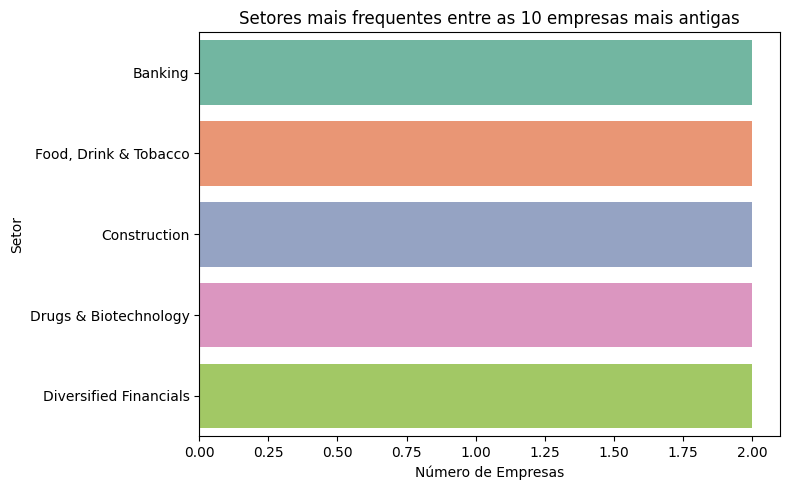

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=empresas_mais_antigas, y='Industry', palette='Set2', hue='Industry', legend=False)
plt.title('Setores mais frequentes entre as 10 empresas mais antigas')
plt.xlabel('Número de Empresas')
plt.ylabel('Setor')
plt.tight_layout()
plt.show()

#Conclusões Gerais

* Presença de setores tradicionais e resilientes -
Os setores representados (ex: Banking, Construction, Food, Drink & Tobacco, Drugs & Biotechnology) são setores com longa história, tradição e relevância económica consolidada ao longo das décadas, o que indica resiliência ao tempo e às crises.

* Nenhum setor domina — os 5 setores listados têm exatamente 2 empresas cada, sugerindo uma distribuição equilibrada entre diferentes ramos de atividade. Qualquer empresa, desde que apresente adaptabilidade ás condições do momento, possui a capacidade de fazer sucesso em qualquer época



#**Pergunta 4  - Quais os setores que evoluíram mais ao longo dos anos?**

Analisar a evolução dos setores ao longo dos anos permite identificar quais as áreas de atividade que mais cresceram ou ganharam relevância no panorama económico global. Mudanças tecnológicas, transformações nos hábitos de consumo, transições energéticas e acontecimentos geopolíticos influenciam diretamente o desempenho de diferentes indústrias. Observar esta dinâmica ajuda a perceber tendências de longo prazo, setores emergentes e aqueles que, por diferentes razões, perderam protagonismo. Esta perspetiva temporal é essencial para compreender como o contexto global molda a estrutura e a competitividade das grandes empresas.

De forma a efetuar esta inverstigação, recorrerei a um dataset da Global Forbes 2000, referente ao ano de 2008.

Leitura do dataset de 2008

In [ ]:
antigo_df = pd.read_csv("Forbes_2000_2008_converted.csv", na_values=na_vals)

Converter a coluna de lucros no dataset antigo para o tipo numérico, evitando erros

In [ ]:
antigo_df['Profits'] = pd.to_numeric(antigo_df['Profits'], errors='coerce')

Irei proceder a duas variáveis de forma a avaliar a evolução dos setores: aumento do número de empresas e subida no lucro absoluto

Obtenção do número de empresas por setor nos anos 2008 e 2022

In [ ]:
num_empresas_2022 = df_forbes['Industry'].value_counts().reset_index()
num_empresas_2022.columns = ['Industry', 'Count_2022']

num_empresas_2008 = antigo_df['Industry'].value_counts().reset_index()
num_empresas_2008.columns = ['Industry', 'Count_2008']

Merge de ambos os anos

In [ ]:
comparacao_setores = pd.merge(num_empresas_2008, num_empresas_2022, on='Industry', how='inner')

Cálculo da diferença de empresas de cada setor em 2022 comparado a 2008

In [ ]:
comparacao_setores['Diff_Count'] = comparacao_setores['Count_2022'] - comparacao_setores['Count_2008']

Top 5 Setores que mais cresceram em número de empresas

In [ ]:
top_crescimento_setores = comparacao_setores.sort_values(by='Diff_Count', ascending=False).head(5)

Gráfico ilustrativo

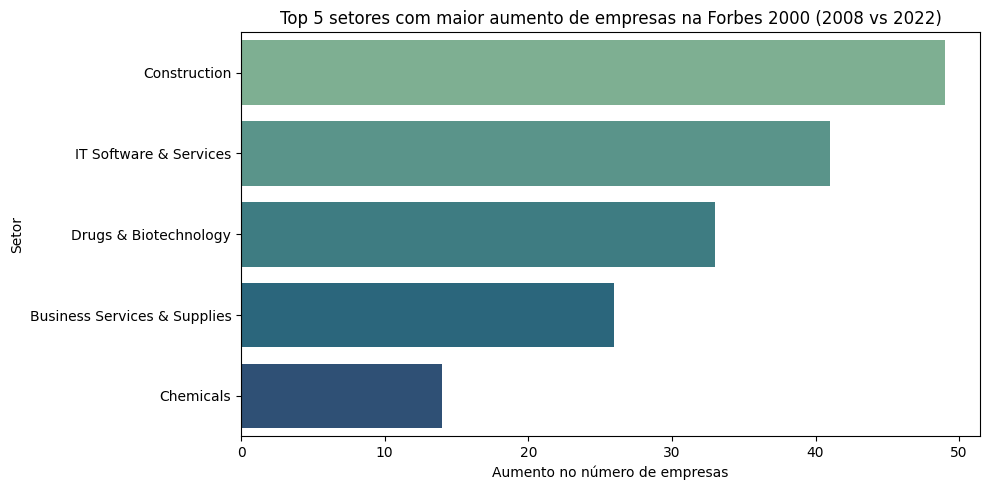

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top_crescimento_setores, x='Diff_Count', y='Industry', palette='crest', hue='Industry', legend=False)
plt.title('Top 5 setores com maior aumento de empresas na Forbes 2000 (2008 vs 2022)')
plt.xlabel('Aumento no número de empresas')
plt.ylabel('Setor')
plt.tight_layout()
plt.show()

Como é possível observar, o setor que mais aumentou ao longo desse intervalo de 14 anos foi o setor da construção, motivado por planos de reconstrução após o acontecimento de certas crises, como a de 2008 e relacionada à pandemia da covid-19 seguido do setor de IT software & services, favorecidos pela ascensão de tecnologias revolucionárias como o cloud computing, AI, entre outros. Os setores mais relacionados com a medicina (Drugs & Biotechnology, Chemicals), foram motivados igualmente pela evolução tecnológica e pela pandemia, que trouxe maior visibilidade para estas áreas.

Agora, analisemos o oposto: quais setores perderam mais popularidade/relevância?

Top 5 setores que mais diminuiram o seu número de empresas

In [ ]:
least_crescimento_setores = comparacao_setores.sort_values(by='Diff_Count', ascending=False).tail(5)

Gráfico ilustrativo

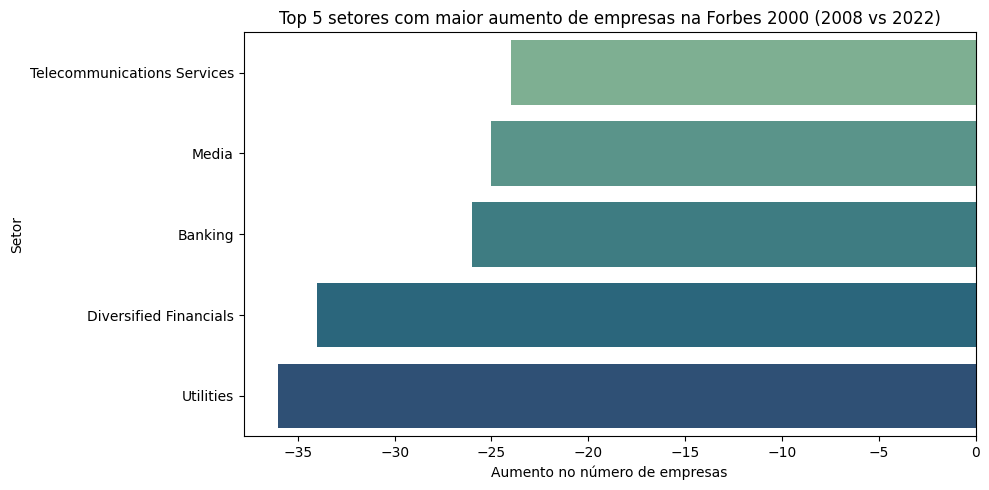

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=least_crescimento_setores, x='Diff_Count', y='Industry', palette='crest', hue='Industry', legend=False)
plt.title('Top 5 setores com maior aumento de empresas na Forbes 2000 (2008 vs 2022)')
plt.xlabel('Aumento no número de empresas')
plt.ylabel('Setor')
plt.tight_layout()
plt.show()

*  Como podemos observar, o setor das utilities foi aquele que manifestou um maior volume de perdas na presença da lista da forbes. Este acontecimento pode estar associado, por exemplo à corrente de transição energética, onde houve reestruturação significativa em muitos países (mesmo relativamente a leis) que prejudicou e levou à falência de empresas que utilizavam outros meios de energia (carvão, gás natural) e não se conseguiram adaptar ou mesmo ter ambiente para existir

* No caso do banking e dos diversed finantials, houveram muitas empresas a decretar falência após eventos como uma crise financeira mundial em 2008-2009, a crise de 2012 na zona euro relacionada à troika e a pandemia da covid-19

* Em relação aos media, o setor sofreu um enorme impacto com a digitalização, a ascensão das plataformas online e o declínio do consumo de mídia tradicional. Muitas empresas não conseguiram adaptar-se ao novo modelo digital, perdendo relevância económica ou sendo adquiridas por gigantes tecnológicos.

* Em relação às telecomunicações, apesar de ser um setor essencial, passou por intensa consolidação e competição feroz. Muitas empresas fundiram-se ou tornaram-se subsidiárias de grandes grupos, deixando de aparecer de forma independente na Forbes. Além disso, gigantes de tecnologia começaram a absorver parte do seu mercado, como no caso de apps de comunicação que substituem chamadas tradicionais.




Agora, passemos para os setores que mais cresceram e decresceram em lucro absoluto

Cálculo (soma) dos valores de lucro absoluto por região em 2008 e 2022

In [ ]:
lucros_2022 = df_forbes.groupby('Industry')[['Profits (Billions)']].sum().reset_index()
lucros_2022.columns = ['Industry', 'Profits_2022']

lucros_2008 = antigo_df.groupby('Industry')[['Profits']].sum().reset_index()
lucros_2008.columns = ['Industry', 'Profits_2008']


Merge e cálculo da diferença de lucro absoluto de 2088 para 2022

In [ ]:
lucros_comparados = pd.merge(lucros_2022, lucros_2008, on='Industry', how='inner')
lucros_comparados['Diff_Profit'] = lucros_comparados['Profits_2022'] - lucros_comparados['Profits_2008']

Top 5 setores que mais aumentaram lucro absoluto (Com gráfico ilustativo)



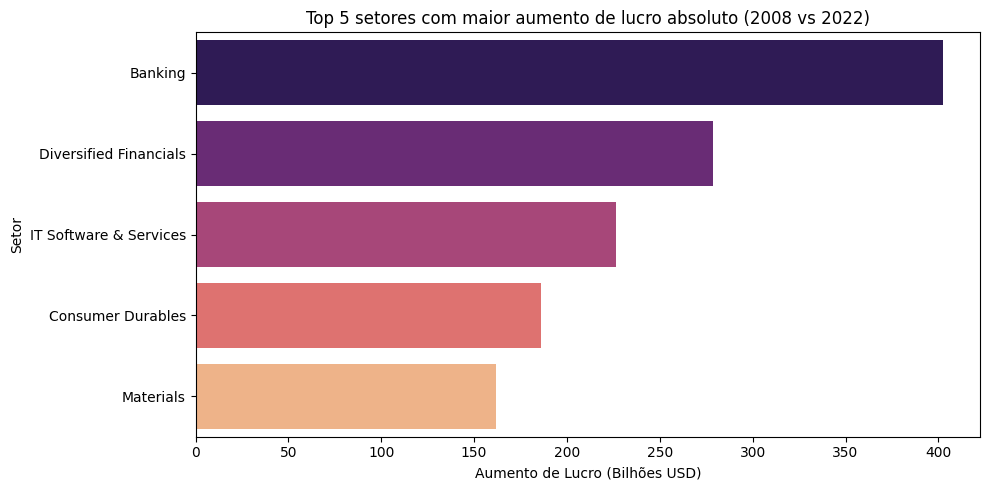

In [ ]:
# Top 5 setores que mais aumentaram lucro absoluto (usar head para obter os que estão em cima na lista)
top_crescimento_lucro = lucros_comparados.sort_values(by='Diff_Profit', ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_crescimento_lucro, x='Diff_Profit', y='Industry', palette='magma', hue='Industry', legend=False)
plt.title('Top 5 setores com maior aumento de lucro absoluto (2008 vs 2022)')
plt.xlabel('Aumento de Lucro (Bilhões USD)')
plt.ylabel('Setor')
plt.tight_layout()
plt.show()


Como é possível ver, o setor de Banking, como esperado, tendo em conta o domínio do setor pelo planeta, apresentou maior valor de lucro absoluto. Em segundo lugar, vem os diversed financials, que, como pudemos igualmente observar, é um setor altamento lucrativo. Tendo também em conta que o setor de IT foi dos que mais aumentou em número de empresas nos ultimos anos, faz sentido encontrar-se no 3o lugar

Agora, analisemos os 5 setores que tiveram mais prejuízo nos últimos anos:

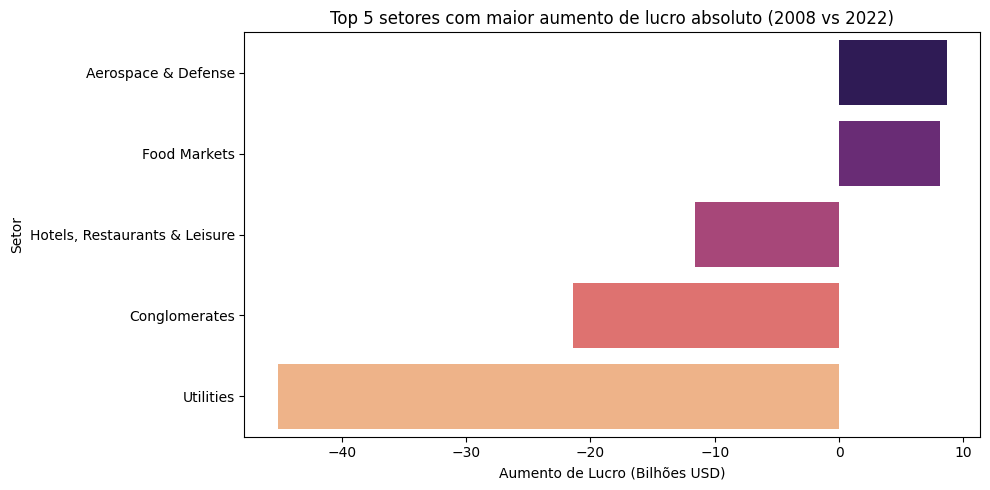

In [ ]:
# Top 5 setores com menos lucro absoluto (ir buscar ao fim da lista, recorrendo ao tail)
least_crescimento_lucro = lucros_comparados.sort_values(by='Diff_Profit', ascending=False).tail(5)

plt.figure(figsize=(10, 5))
sns.barplot(data=least_crescimento_lucro, x='Diff_Profit', y='Industry', palette='magma', hue='Industry', legend=False)
plt.title('Top 5 setores com maior aumento de lucro absoluto (2008 vs 2022)')
plt.xlabel('Aumento de Lucro (Bilhões USD)')
plt.ylabel('Setor')
plt.tight_layout()
plt.show()


Como se pode ver, o setor das Utilities, pelos motivos já abordados anteriormente, apresenta-se como o setor com maior prejuízo nos últimos anos. No caso dos conglomerates, a justificativa é similar à questão dos bancos: crises como a de 2008 que geraram instabilidade e incapacidade de adaptação. No caso dos hotéis,restaurantes e leisure, o valor negativo está fortemente influenciado pela pandemia da covid-19, uma vez que, durante o tempo de quarentena e de emergência, ocorreu uma queda brutal no turismo, o que forçou vários restaurantes e hotéis a fechar por falta de clientela. A pandemia afetou também (embora em menor escala) os supermercados e o setor de aerospace & defense

#**Pergunta 5 - Empresas Estatais ou Não Estatais: quais apresentam maior rentabilidade e desempenho económico?**

As empresas podem ser classificadas, de forma geral, como estatais ou não estatais, consoante o seu controlo acionista. Uma empresa estatal é aquela que é controlada pelo governo, total ou maioritariamente.

Já uma empresa não estatal (ou privada) é gerida por entidades ou investidores do setor privado, sem controlo governamental direto.

Ao longo desta pergunta, iremos tentar compreender até que ponto a natureza da sua gestão influencia a rentabilidade, a valorização de mercado e outros indicadores económicos. Por outras palavras, é melhor possuir empresas sob gestão do governo ou as empresas geridas por companhias privadas/sem controlo maioritário do governo possuem melhor performance?

Carregamento do dataset que possui as empresas que são estatais ou não estatais (por indice)

In [ ]:
df_estatal = pd.read_csv("Forbes_2000_Classificacao_Estatal_2022.csv", na_values=na_vals)

Cálculo da margem de lucro

In [ ]:
df_forbes_merged['ProfitMargin_%'] = (df_forbes_merged['Profits (Billions)'] / df_forbes_merged['Revenue (Billions)']) * 100

Adicionar coluna da classificação, com os valores do dataframe introduzido (como tem apenas uma coluna, não é necessário fazer merge)

In [ ]:
df_forbes_merged['Classificacao'] = df_estatal['Classificação']

Obtenção do número de empresas estatais por região

       Região  Num_Empresas_Estatais
         Asia                     13
       Europe                      4
  Middle East                      2
South America                      2


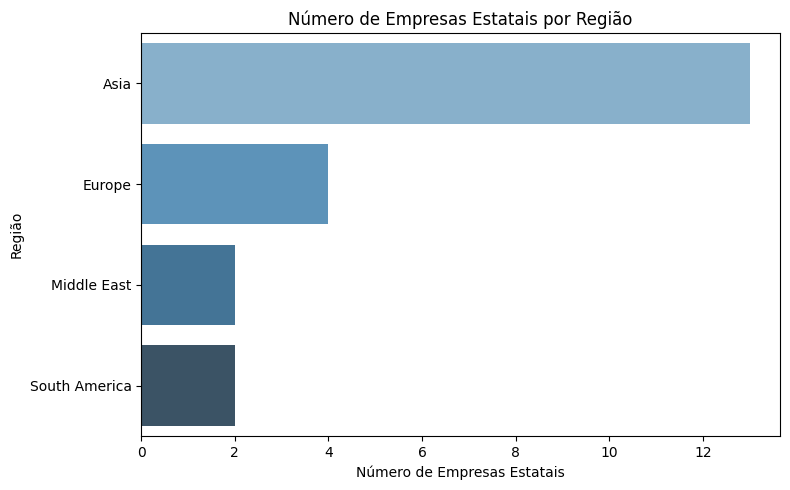

In [ ]:
df_estatais = df_forbes_merged[df_forbes_merged['Classificacao'] == 'Estatal']

estatais_por_regiao = df_estatais['region'].value_counts().reset_index()
estatais_por_regiao.columns = ['Região', 'Num_Empresas_Estatais']

print(estatais_por_regiao.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=estatais_por_regiao, x='Num_Empresas_Estatais', y='Região', palette='Blues_d', hue='Região', legend=False)
plt.title('Número de Empresas Estatais por Região')
plt.xlabel('Número de Empresas Estatais')
plt.ylabel('Região')
plt.tight_layout()
plt.show()


Como é possível observar, a Ásia possui o maior número de empresas estatais

Possuimos conhecimento acerca do número absoluto de empresas estatais de cada região. Agora, seria interessante observar quais são as regiões que efetivamente recorrem-se mais a empresas estatais como motor económico. Para isso, iremos calcular a percentagem de empresas estatais por região:

In [ ]:
estatais_por_regiao = estatais_por_regiao.set_index('Região')['Num_Empresas_Estatais'].sort_index() #Redefinição do índice com a coluna da região de forma a garantir compatibilidade com a estrutura do companies_by_region

percentual_estatais = pd.concat([companies_by_region, estatais_por_regiao], axis=1)
percentual_estatais.columns = ['Total_Empresas', 'Num_Empresas_Estatais']
#Preencher Regiões que apresentam valores nulos (por não terem empresas estatais) com 0 no seu número de empresas, permitindo a realização do cálculo
percentual_estatais['Num_Empresas_Estatais'] = percentual_estatais['Num_Empresas_Estatais'].fillna(0)
percentual_estatais['Percentual_Estatais (%)'] = (percentual_estatais['Num_Empresas_Estatais'] / percentual_estatais['Total_Empresas']) * 100

print(percentual_estatais.sort_values(by='Percentual_Estatais (%)', ascending=False))


               Total_Empresas  Num_Empresas_Estatais  Percentual_Estatais (%)
South America              35                    2.0                 5.714286
Middle East                60                    2.0                 3.333333
Asia                      766                   13.0                 1.697128
Europe                    430                    4.0                 0.930233
Africa                     17                    0.0                 0.000000
North America             661                    0.0                 0.000000
Oceania                    30                    0.0                 0.000000


Remover regiões com 0% de empresas estatais

In [ ]:
percentual_estatais = percentual_estatais[percentual_estatais['Percentual_Estatais (%)'] > 0].copy()


Gráfico ilustrativo:

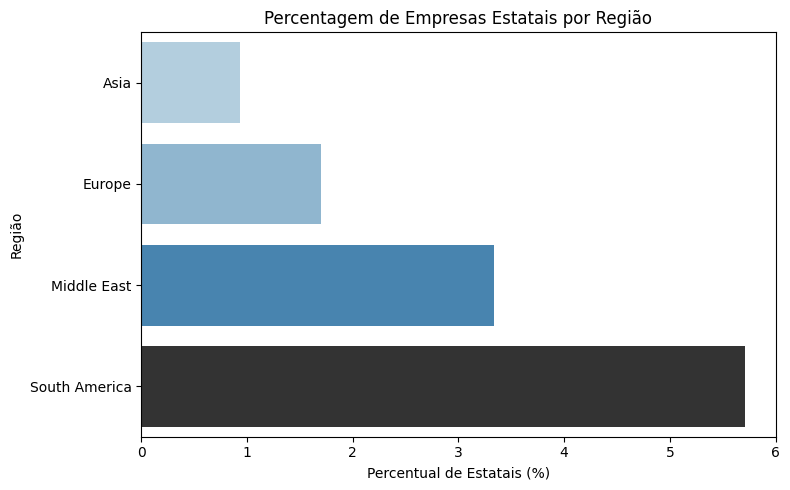

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=percentual_estatais.sort_values(by='Percentual_Estatais (%)', ascending=True),x='Percentual_Estatais (%)',y=percentual_estatais.index,palette='Blues_d',hue='Percentual_Estatais (%)',legend=False)
plt.title('Percentagem de Empresas Estatais por Região')
plt.xlabel('Percentual de Estatais (%)')
plt.ylabel('Região')
plt.tight_layout()
plt.show()

Como é possível observar, A América do Sul é o continente que possui maior predominância de empresas estatais na sua região, seguido do Médio Oriente.

Nesta etapa do processo, surge uma questão pertitente: Sabemos das regiões com mais empresas estatais e onde as mesmas são mais predominantes, mas que empresas são essas? Quais as áreas de atuação das empresas controladas pelo governo? Primeiramente, vamos listar as empresas presentes, por região:

In [ ]:
empresas_estatais_por_regiao = df_estatais.groupby('region')[['Organization Name', 'Industry']]

for regiao, grupo in empresas_estatais_por_regiao:
    print(f"\nRegião: {regiao}\n")

    #Percorre todas as linhas relativas a empresas estatais
    for _, row in grupo.iterrows():
        print(f"- {row['Organization Name']} ({row['Industry']})")



Região: Asia

- China Construction Bank (Banking)
- Agricultural Bank of China (Banking)
- Bank of China (Banking)
- China Merchants Bank (Banking)
- Postal Savings Bank Of China (PSBC) (Banking)
- China Mobile (Telecommunications Services)
- Sinopec (Oil & Gas Operations)
- China State Construction Engineering (Construction)
- China Communications Construction (Construction)
- China Railway Group (Construction)
- China Railway Construction (Construction)
- Korea Electric Power (Utilities)
- China Development Bank Financial Leasing (Banking)

Região: Europe

- Gazprom (Oil & Gas Operations)
- Rosneft (Oil & Gas Operations)
- Enel (Utilities)
- EDF  (Utilities)

Região: Middle East

- Saudi Arabian Oil Company (Saudi Aramco) (Oil & Gas Operations)
- ADNOC Drilling (Oil & Gas Operations)

Região: South America

- Petrobras (Oil & Gas Operations)
- Banco do Brasil (Banking)


De acordo com os dados fornecidos, é possível visualizar que praticamente todas as empresas estão situadas em setores estratégicos dos países em questão: podemos observar isso com a Arábia Saudita que, como já vimos lá atrás, manifesta uma abundância imensa em petróleo. Dado este facto, apreseta uma empresa dedicada ao petróleo. O mesmo verifica-se com a Rússia, que possuindo abundância de petróleo e gás natural, tem uma empresa no mesmo setor (Gazprom).

Podemos constatar este fenómeno, principalmente, em relação à China, que apresenta uma companhia em basicamente todos os setores essenciais para a população, desde telecomunicações, railways(caminhos de ferro), um banco nacional, construção civil e por aí em diante. Em suma, o sucesso económico da China deve-se ao seu modelo económico baseado no controlo estatal de setores económicos, onde o estado não atua apenas como regulador, mas como agente económico também.

Resumidamente, é possível um país ter sucesso investindo em empresas estatais, se tiver um foco e objetivo claro

Já sabemos que é possível possuir sucesso com empresas estatais. Contudo, fica agora a questão: de forma geral, vale mais a pena basear a economia de um país em empresas estatais ou não estatais? Para responder a isso, pegaremos em algumas métricas económicas já mencionadas anteriormente

Correção de valores infinitos ou inválidos na margem de lucro

In [ ]:
# Converte a coluna 'ProfitMargin_%' para tipo numérico, substituindo valores inválidos por NaN
df_forbes_merged['ProfitMargin_%'] = pd.to_numeric(df_forbes_merged['ProfitMargin_%'], errors='coerce')

# Substitui valores infinitos (resultantes de divisões inválidas) por valores ausentes (pd.NA)
df_forbes_merged.loc[df_forbes_merged['ProfitMargin_%'].isin([float('inf'), float('-inf')]), 'ProfitMargin_%'] = pd.NA

Agrupamento e cálculo das métricas base por tipo de empresa (estatal vs não estatal)

In [ ]:
agrupado = df_forbes_merged.groupby('Classificacao').agg({
    'Organization Name': 'count',
    'Revenue (Billions)': 'mean',
    'Profits (Billions)': 'mean',
    'ProfitMargin_%': 'mean',
    'Market Value (Billions)': 'mean'
}).rename(columns={'Organization Name': 'Num_Empresas'}).reset_index()

Cálculo do lucro total por grupo

In [ ]:
total_lucros = df_forbes_merged.groupby('Classificacao')['Profits (Billions)'].sum().reset_index()
total_lucros.rename(columns={'Profits (Billions)': 'Lucro_Total_B'}, inplace=True)

Combinação dos valores de ambas as tabelas (indicando também o número de empresas estatais e não estatais)

In [ ]:
df_final = pd.merge(agrupado, total_lucros, on='Classificacao')
print(df_final[['Classificacao','Num_Empresas']])

  Classificacao  Num_Empresas
0       Estatal            21
1   Não Estatal          1978


Gráfico ilustrativo do lucro médio

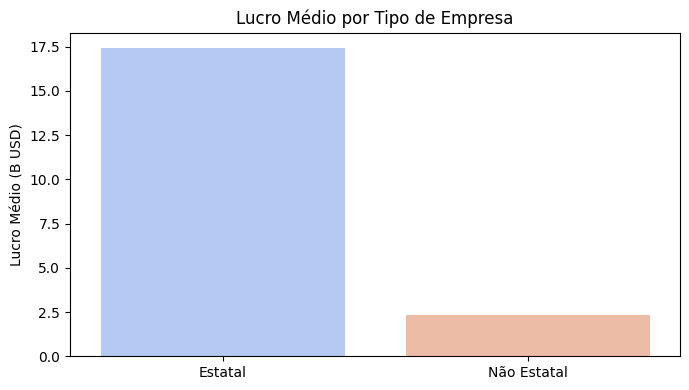

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df_final, x='Classificacao', y='Profits (Billions)', palette='coolwarm', hue='Classificacao', legend=False)
plt.title('Lucro Médio por Tipo de Empresa')
plt.ylabel('Lucro Médio (B USD)')
plt.xlabel('')
plt.tight_layout()
plt.show()

Como é possível observar, as Empresas Estatais possuem um lucro médio muito mais elevado comparativamente às não estatais. Isto deve-se à sua menor presença numérica, bem como à concentração, como já destacado, das empresas estatais em setores estratégicos, como exploração de petróleo, energia, etc, setores altamente lucrativos

Como já foi observado em outras questões, muitas das vezes o lucro absoluto de uma região não se traduz em eficiência. Dito isto, observemos neste momento os resultados das margens de lucro para ambos os tipos:

Gráfico ilustrativo da margem de lucro média

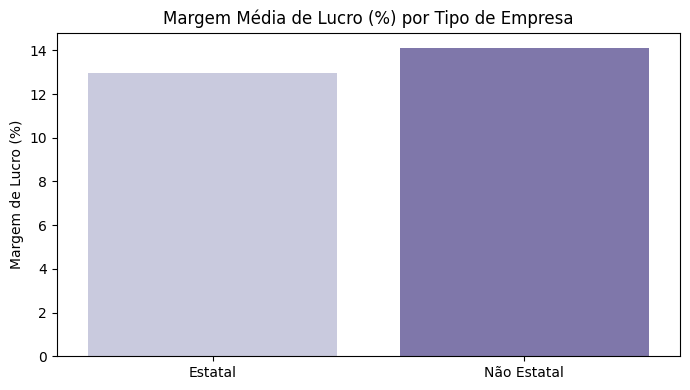

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df_final, x='Classificacao', y='ProfitMargin_%', palette='Purples', hue='Classificacao', legend=False)
plt.title('Margem Média de Lucro (%) por Tipo de Empresa')
plt.ylabel('Margem de Lucro (%)')
plt.xlabel('')
plt.tight_layout()
plt.show()


Experimentemos, agora, com alguns setores inovadores (setores mais recentes ou em grandes transformações, que têm evoluindo exponencialmente nos últimos tempos, revelando-se o futuro)

In [ ]:
#Setores que considerei inovadores
setores_inovadores = ['IT Software & Services', 'Technology Hardware & Equipment', 'Retailing', 'Consumer Durables']
empresas_setores_inovadores = df_forbes_merged[df_forbes_merged['Industry'].isin(setores_inovadores)]

#Contagem do número de empresas estatais e não estatais que se encontram na lista de setores inovadores
contagem_inovadores = empresas_setores_inovadores.groupby(['Classificacao'])['Organization Name'].count().reset_index()
contagem_inovadores.columns = ['Classificacao', 'Num_Empresas_Setor_Inovador']

#Média da margem de lucro nos setores inovadores
margem_inovadores = empresas_setores_inovadores.groupby('Classificacao')['ProfitMargin_%'].mean().reset_index()
margem_inovadores.columns = ['Classificacao', 'Margem_Media_Setor_Inovador']

print("Número de empresas em setores inovadores por tipo de empresa:")
print(contagem_inovadores)

print("\nMargem média de lucro nos setores inovadores por tipo de empresa:")
print(margem_inovadores)

Número de empresas em setores inovadores por tipo de empresa:
  Classificacao  Num_Empresas_Setor_Inovador
0   Não Estatal                          287

Margem média de lucro nos setores inovadores por tipo de empresa:
  Classificacao  Margem_Media_Setor_Inovador
0   Não Estatal                    24.815403


Como pudemos ver, apesar da diferença estonteante do lucro médio a favor das empresas estatais, as empresas não estatais possuem maior margem de lucro. É observável também que as empresas estatais não apresentam empresas relevantes em setores evolutivos, ao passo que estes são significativamente relevantes e lucrativos nos setores não estatais. Isto deve-se, por exemplo, ao facto de:

* Empresas estatais operam em setores de volume e interesse público -
Como referido antes, muitas estatais estão em setores estratégicos que geram receitas altíssimas, contudo com margens mais controladas por regulação ou objetivos de interesse nacional.

* Menor pressão competitiva ou de mercado em estatais -
Algumas estatais operam em regimes de monopólio ou com apoio do Estado, o que permite lucro alto em valor absoluto, mas pode gerar ineficiências internas e desencorajamento de setores em evolução por falta de competitividade

Após analisar a margem média de lucro entre empresas estatais e não estatais, importa agora compreender a consistência dos resultados financeiros de cada grupo, analisando o desvio padrão do lucro. Esta métrica permite perceber o grau de variação entre os lucros, identificando se os resultados são mais estáveis ou voláteis dentro de cada categoria.

Obtenção do desvio padrão, para ambos os estilos de emrpresas

In [ ]:
desvio_lucro = df_forbes_merged.groupby('Classificacao')['Profits (Billions)'].std().reset_index()

Seleção das colunas e demonstração de resultados

Desvio padrão do lucro por tipo de empresa:
  Classificacao  Desvio_Padrao_Lucro
0       Estatal            24.198294
1   Não Estatal             5.481159


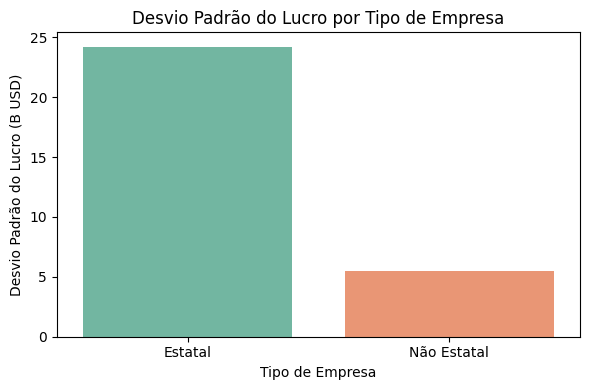

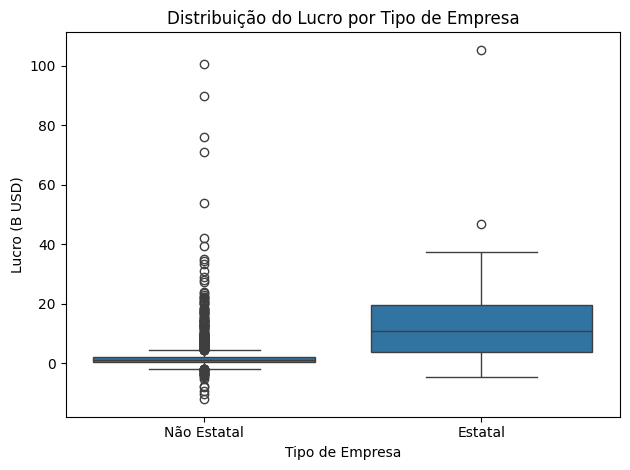

In [ ]:
desvio_lucro.columns = ['Classificacao', 'Desvio_Padrao_Lucro']

print("Desvio padrão do lucro por tipo de empresa:")
print(desvio_lucro)

plt.figure(figsize=(6, 4))
sns.barplot(data=desvio_lucro, x='Classificacao', y='Desvio_Padrao_Lucro', palette='Set2', hue='Classificacao', legend=False)
plt.title('Desvio Padrão do Lucro por Tipo de Empresa')
plt.xlabel('Tipo de Empresa')
plt.ylabel('Desvio Padrão do Lucro (B USD)')
plt.tight_layout()
plt.show()

sns.boxplot(data=df_forbes_merged, x='Classificacao', y='Profits (Billions)')
plt.title('Distribuição do Lucro por Tipo de Empresa')
plt.xlabel('Tipo de Empresa')
plt.ylabel('Lucro (B USD)')
plt.tight_layout()
plt.show()

Os resultados revelam que as empresas não estatais apresentam um desvio padrão de lucro significativamente inferior, o que indica uma maior estabilidade e previsibilidade nos seus resultados financeiros (mesmo apesar do maior número de  outliers). Por outro lado, o elevado desvio nas estatais sugere uma grande disparidade de lucros entre as empresas deste grupo, refletindo uma maior dependência de setores específicos e maior variabilidade no desempenho individual.

Após analisar os lucros e margens médias, torna-se pertinente avaliar a eficiência operacional em função da força de trabalho. Para isso, recorre-se à métrica de rentabilidade por empregado, que permite perceber quanto lucro, em média, é gerado por cada colaborador nas empresas estatais e não estatais, oferecendo uma perspetiva mais ajustada ao nível de produtividade individual

Cálculo da média da receita e do número de empregados, por tipo de empresa

In [ ]:
df_forbes_merged['Total Employees'] = pd.to_numeric(df_forbes_merged['Total Employees'], errors='coerce')

receita_media = df_forbes_merged.groupby('Classificacao')['Revenue (Billions)'].mean().reset_index()
empregados_medios = df_forbes_merged.groupby('Classificacao')['Total Employees'].mean().reset_index()

Merge dos dados e demonstração de resultados

Receita média por empregado (B USD):
  Classificacao  Receita por Empregado (B USD)
0       Estatal                       0.000644
1   Não Estatal                       0.000476


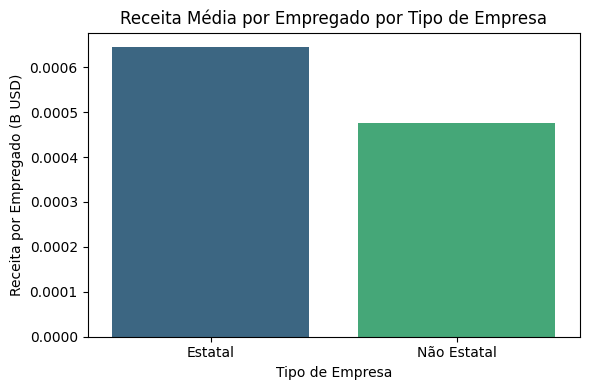

In [ ]:
receita_empregado_df = pd.merge(receita_media, empregados_medios, on='Classificacao')

#Fórmula da receita por empregado (Receita Média/Numero Médio de empregados)
receita_empregado_df['Receita por Empregado (B USD)'] = receita_empregado_df['Revenue (Billions)'] / receita_empregado_df['Total Employees']

print("Receita média por empregado (B USD):")
print(receita_empregado_df[['Classificacao', 'Receita por Empregado (B USD)']])

plt.figure(figsize=(6, 4))
sns.barplot(data=receita_empregado_df, x='Classificacao', y='Receita por Empregado (B USD)', palette='viridis', hue='Classificacao', legend=False)
plt.title('Receita Média por Empregado por Tipo de Empresa')
plt.xlabel('Tipo de Empresa')
plt.ylabel('Receita por Empregado (B USD)')
plt.tight_layout()
plt.show()

Os resultados demonstram que, em média, as empresas estatais apresentam maior rentabilidade por trabalhador, evidenciando uma capacidade de gerar valor significativo mesmo com estruturas de maior dimensão. Este dado reforça a ideia de que, apesar de menos eficientes em termos marginais, as estatais conseguem manter níveis elevados de produção de valor por colaborador, sobretudo devido à sua atuação em setores de grande escala económica.

Por fim, é igualmente relevante perceber qual o peso real que cada grupo representa no lucro global gerado. Através da análise da contribuição percentual para o lucro total, é possível avaliar o impacto efetivo das empresas estatais e não estatais no panorama económico mundial, independentemente do número de empresas envolvidas.

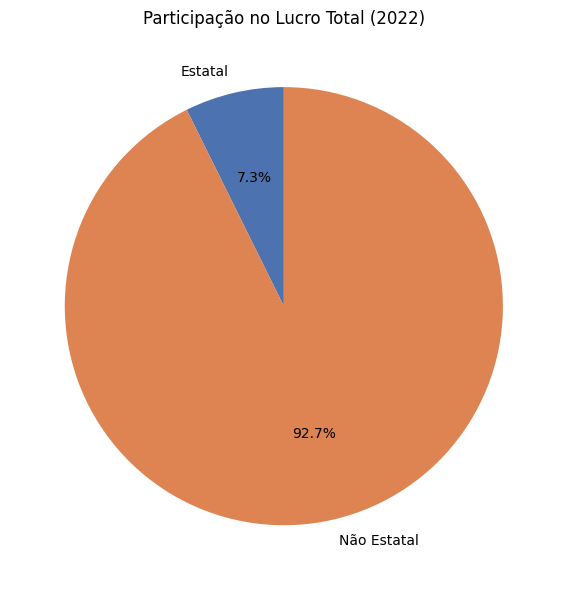

In [ ]:


# Gráfico da Participação de cada tipo no lucro total
plt.figure(figsize=(6, 6))
plt.pie(df_final['Lucro_Total_B'], labels=df_final['Classificacao'], autopct='%1.1f%%', startangle=90, colors=['#4c72b0', '#dd8452'])
plt.title('Participação no Lucro Total (2022)')
plt.tight_layout()
plt.show()


Como seria de esperar, perante a diferença do número de empresas estatais para as não estatais, as empresas não estatais possuem maior participação no lucro total, sendo de realçar que, mesmo assim, as empresas estatais possuem uma fatia significativa

#Conclusões Gerais

A análise detalhada dos dados revela que tanto as empresas estatais como as não estatais apresentam vantagens distintas, dependendo do critério considerado.

* No caso de países que recorrem a empresas estatais, estas atuam unicamente em setores estratégicos. Ao atuarem em áreas pretendidas pelo Estado, o mesmo procura muitas das vezes assegurar a sua soberania e monopólio do comércio. Toda esta mobilização gera uma produção de lucro e uma capacidade operacional elevadas, como se pode ver nos valores de lucro médio e de rentabilidade por empregado. Contudo, esta monopolização e concentração em setores prioritários provoca o desencorajamento de empresas de setores em ascensão, devido à falta de incentivos, à rigidez estrutural e à menor abertura à inovação(como se pode observar, nem existem empresas estatais de setores inovadores na forbes, enquanto que existem 287 empresas não estatais nas mesmas áreas). Isto contribui para uma menor presença estatal em setores inovadores, como o IT, que acabam por ser dominados por empresas não estatais, mais ágeis e adaptáveis às rápidas mudanças de mercado. Adicionalmente, a análise revela que as empresas estatais apresentam um desvio padrão de lucro significativamente superior, refletindo uma grande disparidade nos resultados financeiros entre as empresas do grupo, com casos de lucros extremamente elevados e outros bastante mais modestos — um sinal de que o desempenho estatal é, por vezes, desigual e fortemente dependente do setor específico em que opera.

 Como mencionado, um exemplo de uma boa aplicação do sistema estatal é a China, que possui empresas estatais para os setores cruciais para garantir soberania, estabilidade económica e controlo estratégico, autorizando igualmente um forte investimento em empresas não estatais para os restantes setores, incentivando a inovação, a competitividade e o dinamismo do mercado.

* As empresas não estatais atuam maioritariamente em setores inovadores e competitivos, onde demonstram elevada agilidade e capacidade de adaptação. A ausência de vinculação a objetivos estatais permite-lhes operar com maior liberdade e foco na eficiência, o que se reflete numa margem de lucro média superior e numa maior estabilidade dos resultados, comprovada pelo baixo desvio padrão do lucro.
Apesar de apresentarem lucros médios mais baixos do que as estatais, as não estatais são mais consistentes e previsíveis. Contudo, enfrentam maior pressão competitiva, o que se traduz num maior número de outliers e maior exposição a riscos de mercado.
No geral, estas empresas são fundamentais para o crescimento económico, sendo as principais impulsionadoras da inovação, da eficiência e da diversificação dos setores emergentes.

#Conclusão Final

A análise da lista Forbes Global 2000 de 2022 proporcionou uma visão abrangente e esclarecedora sobre o panorama econômico global. Ao explorar os dados das maiores empresas cotadas em bolsa no mundo, foi possível identificar padrões relevantes em termos de setores predominantes, distribuição geográfica das corporações, e desempenho financeiro das organizações de maior destaque.

Pudemos igualmente explorar que variáveis eram mais proporcionais ao lucro, buscando obter aquilo que são os seus valores ideias para o maior lucro possível

Este projeto proporcionou-me a possibilidade de ver os diferentes setores maioritariamente presentes ao longo da humanidade e que se mantém até hoje relevantes

Este estudo deu margem a uma análise mais ampla daquilo que são os setores com crescimento mais exponencial

Por fim, coneguimos observar se havia alguma vantagem em assumir empresas controladas pelo estado ou se é preferível ter empresas com pouca influência do mesmo ou privadas